## Requirements

In [2]:
%pip install scipy networkx matplotlib

A Song of Ice and Fire network dataset – KONECT. (2017, November). Retrieved from http://konect.cc/networks/asoiaf

## Loading data

In [3]:
import scipy.io
import networkx as nx

In [4]:
# 1. Load the .mtx file as a sparse matrix
sparse_matrix = scipy.io.mmread('asoiaf.mtx')

# 2. Convert the sparse matrix to a NetworkX Graph
# For undirected graphs:
G = nx.from_scipy_sparse_array(sparse_matrix)

# For directed graphs (if applicable):
# G = nx.from_scipy_sparse_array(sparse_matrix, create_using=nx.DiGraph)

# 3. Quick check of the network stats
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 796
Edges: 2823


In [5]:
# Load character name mapping
import pandas as pd

# Load the mapping file
name_mapping_df = pd.read_csv('name-id-mapping-zero-only.csv')
node_to_name = dict(zip(name_mapping_df['Zero-Based ID'], name_mapping_df['Character Name']))

# Helper function to get node name
def get_node_name(node_id):
    """Get character name for a given node ID"""
    return node_to_name.get(node_id, f"Unknown(ID:{node_id})")

# Test the mapping
print(f"Loaded {len(node_to_name)} character mappings")
print(f"Sample: Node 0 = {get_node_name(0)}, Node 59 = {get_node_name(59)}")

Loaded 796 character mappings
Sample: Node 0 = Addam-Marbrand, Node 59 = Jon-Snow


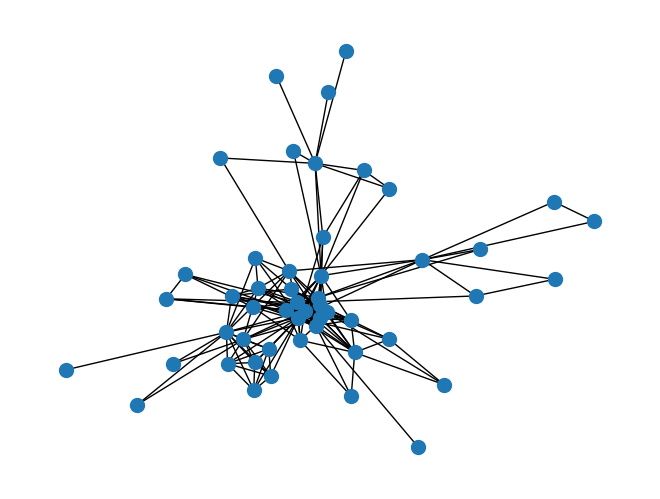

In [6]:
# Get the first X nodes to test visualization
X = 50
subgraph = G.subgraph(list(G.nodes())[:X])
nx.draw(subgraph, node_size=100)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# MICROSCALE ANALYSIS

## 1. Degree Analysis

DEGREE DISTRIBUTION (Number of Links)
Minimum degree: 1
Maximum degree: 122
Average degree: 7.09
Median degree: 3.00
Std dev degree: 12.68
Network density: 0.0089

Top 10 nodes by degree centrality (local connectivity):
  Node 10 (Tyrion-Lannister): 0.1535 (degree: 122)
  Node 59 (Jon-Snow): 0.1434 (degree: 114)
  Node 4 (Jaime-Lannister): 0.1270 (degree: 101)
  Node 2 (Cersei-Lannister): 0.1220 (degree: 97)
  Node 24 (Stannis-Baratheon): 0.1119 (degree: 89)
  Node 68 (Arya-Stark): 0.1057 (degree: 84)
  Node 14 (Catelyn-Stark): 0.0943 (degree: 75)
  Node 138 (Sansa-Stark): 0.0943 (degree: 75)
  Node 15 (Robb-Stark): 0.0931 (degree: 74)
  Node 20 (Eddard-Stark): 0.0931 (degree: 74)



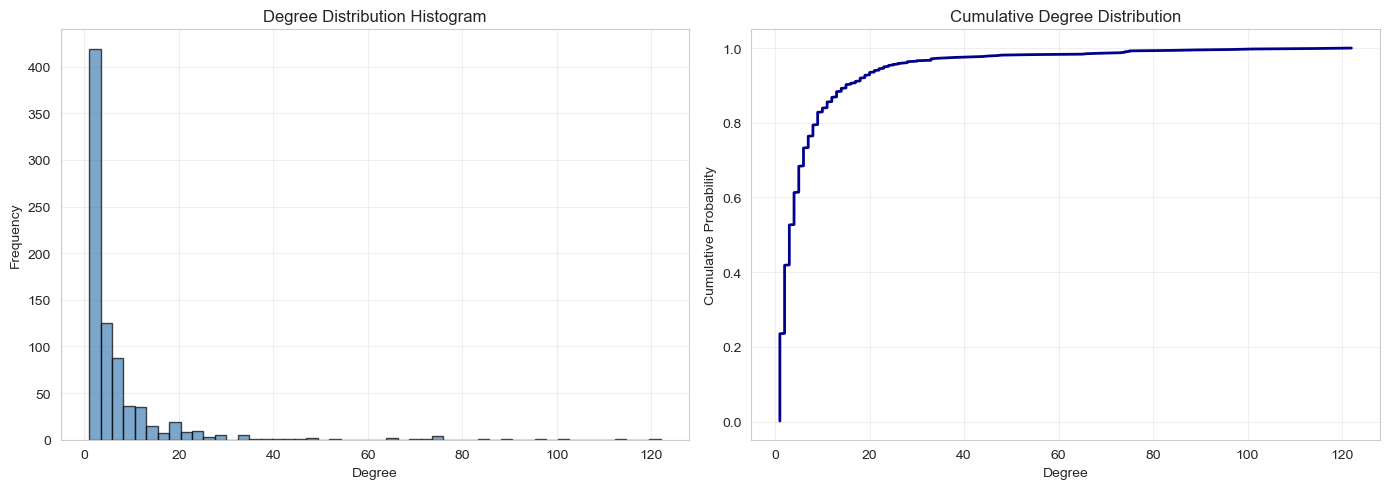

Average neighbor degree range: 2.00 - 122.00
Degree assortativity coefficient: -0.1154
  (Positive = high-degree nodes connect to high-degree nodes)



In [8]:
# 1. DEGREE ANALYSIS - Local Connectivity
# Degree is the number of neighbors each node has (fundamental microscale measure)

degrees = [G.degree(n) for n in G.nodes()]
degree_dict = dict(G.degree())

# Degree statistics
print("=" * 60)
print("DEGREE DISTRIBUTION (Number of Links)")
print("=" * 60)
print(f"Minimum degree: {min(degrees)}")
print(f"Maximum degree: {max(degrees)}")
print(f"Average degree: {np.mean(degrees):.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Std dev degree: {np.std(degrees):.2f}")
print(f"Network density: {nx.density(G):.4f}")
print()

# Degree centrality (normalized degree)
degree_centrality = nx.degree_centrality(G)
top_degree_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by degree centrality (local connectivity):")
for node, centrality in top_degree_nodes:
    print(f"  Node {node} ({get_node_name(node)}): {centrality:.4f} (degree: {degree_dict[node]})")
print()

# Visualize degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution Histogram')
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_degrees = sorted(degrees)
cumulative = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
axes[1].plot(sorted_degrees, cumulative, linewidth=2, color='darkblue')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Cumulative Degree Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Average neighbor degree (assortativity indicator)
avg_neighbor_degree = nx.average_neighbor_degree(G)
print(f"Average neighbor degree range: {min(avg_neighbor_degree.values()):.2f} - {max(avg_neighbor_degree.values()):.2f}")
print(f"Degree assortativity coefficient: {nx.degree_assortativity_coefficient(G):.4f}")
print("  (Positive = high-degree nodes connect to high-degree nodes)")
print()

## 2. Clustering & Triangles Analysis

LOCAL CLUSTERING (Triadic Closure)
Average clustering coefficient: 0.4859
Network transitivity: 0.2090
  (Transitivity = global clustering coefficient)

Min clustering: 0.0000
Max clustering: 1.0000
Median clustering: 0.5000
Std dev clustering: 0.3810

Total triangles in network: 5655
Nodes participating in triangles: 578
Average triangles per node: 21.31
Max triangles per node: 659

Top 10 nodes by clustering coefficient (most embedded in tight communities):
  Node 13 (Aegon-Frey-(son-of-Stevron)): 1.0000 (triangles: 6, degree: 4)
  Node 23 (Rhaenys-Targaryen): 1.0000 (triangles: 1, degree: 2)
  Node 25 (Torrhen-Stark): 1.0000 (triangles: 1, degree: 2)
  Node 26 (Visenya-Targaryen): 1.0000 (triangles: 1, degree: 2)
  Node 39 (Ysilla): 1.0000 (triangles: 15, degree: 6)
  Node 74 (Baelor-Blacktyde): 1.0000 (triangles: 6, degree: 4)
  Node 81 (Gorold-Goodbrother): 1.0000 (triangles: 1, degree: 2)
  Node 83 (Meldred-Merlyn): 1.0000 (triangles: 1, degree: 2)
  Node 84 (Murenmure): 1.0000 (

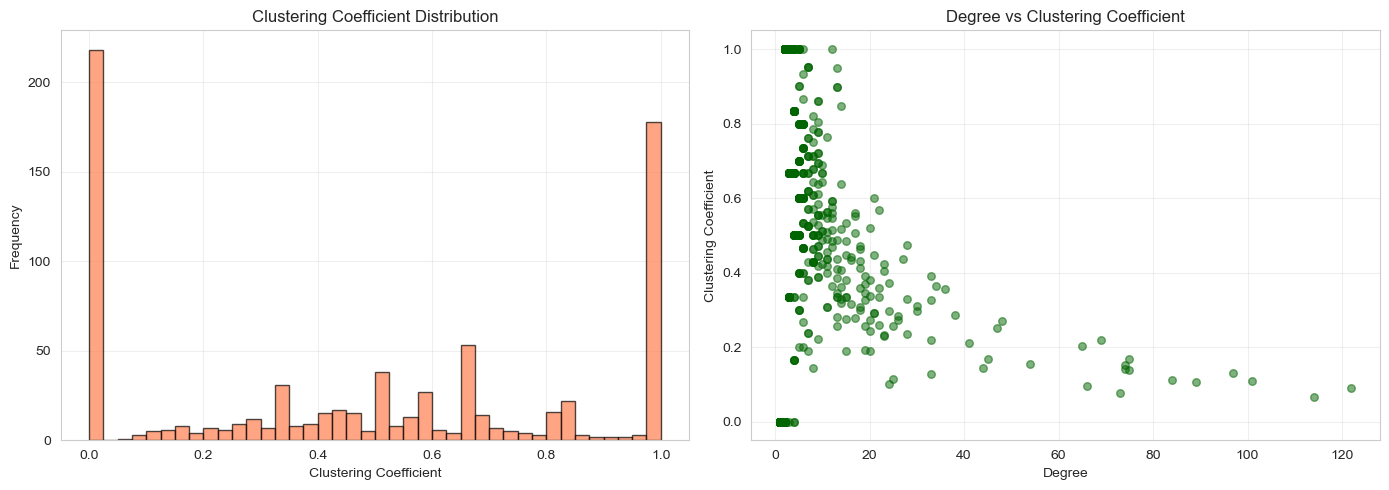

In [8]:
# 2. CLUSTERING ANALYSIS - Local Structure
# Clustering coefficient measures how much neighbors of a node are connected (triangles)

clustering_coeff = nx.clustering(G)
triangles = nx.triangles(G)

print("=" * 60)
print("LOCAL CLUSTERING (Triadic Closure)")
print("=" * 60)
print(f"Average clustering coefficient: {np.mean(list(clustering_coeff.values())):.4f}")
print(f"Network transitivity: {nx.transitivity(G):.4f}")
print(f"  (Transitivity = global clustering coefficient)")
print()

# Clustering statistics
clustering_values = list(clustering_coeff.values())
print(f"Min clustering: {min(clustering_values):.4f}")
print(f"Max clustering: {max(clustering_values):.4f}")
print(f"Median clustering: {np.median(clustering_values):.4f}")
print(f"Std dev clustering: {np.std(clustering_values):.4f}")
print()

# Triangle statistics
triangle_values = list(triangles.values())
print(f"Total triangles in network: {sum(triangle_values) // 3}")  # Divide by 3 since each triangle is counted 3 times
print(f"Nodes participating in triangles: {sum(1 for t in triangle_values if t > 0)}")
print(f"Average triangles per node: {np.mean(triangle_values):.2f}")
print(f"Max triangles per node: {max(triangle_values)}")
print()

# Nodes with highest clustering
top_clustering = sorted(clustering_coeff.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by clustering coefficient (most embedded in tight communities):")
for node, coeff in top_clustering:
    print(f"  Node {node} ({get_node_name(node)}): {coeff:.4f} (triangles: {triangles[node]}, degree: {degree_dict[node]})")
print()

# Visualize clustering distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clustering coefficient histogram
axes[0].hist(clustering_values, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Clustering Coefficient')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Clustering Coefficient Distribution')
axes[0].grid(True, alpha=0.3)

# Scatter: Degree vs Clustering
axes[1].scatter([degree_dict[n] for n in G.nodes()], 
                [clustering_coeff[n] for n in G.nodes()], 
                alpha=0.5, s=30, color='darkgreen')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Clustering Coefficient')
axes[1].set_title('Degree vs Clustering Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

In [9]:
# 3. HIGH DEGREE CLUSTERING ANALYSIS
# Filtering nodes with Degree > 20 and sorting by Clustering Coefficient

print("=" * 60)
print("SOCIAL HUBS IN TIGHT COMMUNITIES (Degree > 20)")
print("=" * 60)

# Filtrar nodos con grado > 20
high_degree_nodes = [node for node, deg in degree_dict.items() if deg > 20]

# Crear lista de tuplas (nodo, clustering, grado, triángulos)
hubs_clustering = [
    (node, clustering_coeff[node], degree_dict[node], triangles[node]) 
    for node in high_degree_nodes
]

# Ordenar por coeficiente de agrupación de forma descendente
hubs_clustering_sorted = sorted(hubs_clustering, key=lambda x: x[1], reverse=True)

print(f"{'Node':<25} | {'Clustering':<12} | {'Degree':<8} | {'Triangles':<10}")
print("-" * 60)

for node, coeff, deg, tri in hubs_clustering_sorted[:10]:
    node_name = get_node_name(node)
    print(f"{node} ({node_name})" + " " * (25 - len(str(node)) - len(node_name) - 3) + f"| {coeff:<12.4f} | {deg:<8} | {tri:<10}")

# Interpretación estadística:
# Si el clustering es alto en un hub, ese hub es el centro de una comunidad densa.
# Si el clustering es bajo, el hub es un "bridge" (conecta grupos que no se conocen).

SOCIAL HUBS IN TIGHT COMMUNITIES (Degree > 20)
Node                      | Clustering   | Degree   | Triangles 
------------------------------------------------------------
171 (Meryn-Trant)        | 0.6000       | 21       | 126       
170 (Ilyn-Payne)         | 0.5671       | 22       | 131       
297 (Loras-Tyrell)       | 0.4735       | 28       | 179       
151 (Jory-Cassel)        | 0.4476       | 21       | 94        
328 (Pycelle)            | 0.4359       | 27       | 153       
125 (Mace-Tyrell)        | 0.4229       | 23       | 107       
57 (Janos-Slynt)         | 0.4032       | 23       | 102       
168 (Gregor-Clegane)     | 0.3902       | 33       | 206       
413 (Lysa-Arryn)         | 0.3732       | 24       | 103       
12 (Varys)               | 0.3636       | 34       | 204       


## 3. Centrality Analysis

LOCAL CENTRALITY MEASURES (Node-level Importance)

Computing betweenness centrality (this may take a moment)...
Top 10 nodes by betweenness centrality (bridges):
  Node 59 (Jon-Snow): 0.1921 (degree: 114)
  Node 10 (Tyrion-Lannister): 0.1622 (degree: 122)
  Node 19 (Daenerys-Targaryen): 0.1184 (degree: 73)
  Node 70 (Theon-Greyjoy): 0.1113 (degree: 66)
  Node 24 (Stannis-Baratheon): 0.1101 (degree: 89)
  Node 4 (Jaime-Lannister): 0.1008 (degree: 101)
  Node 2 (Cersei-Lannister): 0.0887 (degree: 97)
  Node 68 (Arya-Stark): 0.0872 (degree: 84)
  Node 20 (Eddard-Stark): 0.0787 (degree: 74)
  Node 64 (Robert-Baratheon): 0.0782 (degree: 65)

Computing closeness centrality...
Top 10 nodes by closeness centrality (central position):
  Node 10 (Tyrion-Lannister): 0.4763 (degree: 122)
  Node 64 (Robert-Baratheon): 0.4593 (degree: 65)
  Node 20 (Eddard-Stark): 0.4558 (degree: 74)
  Node 2 (Cersei-Lannister): 0.4545 (degree: 97)
  Node 4 (Jaime-Lannister): 0.4520 (degree: 101)
  Node 59 (Jon-Snow

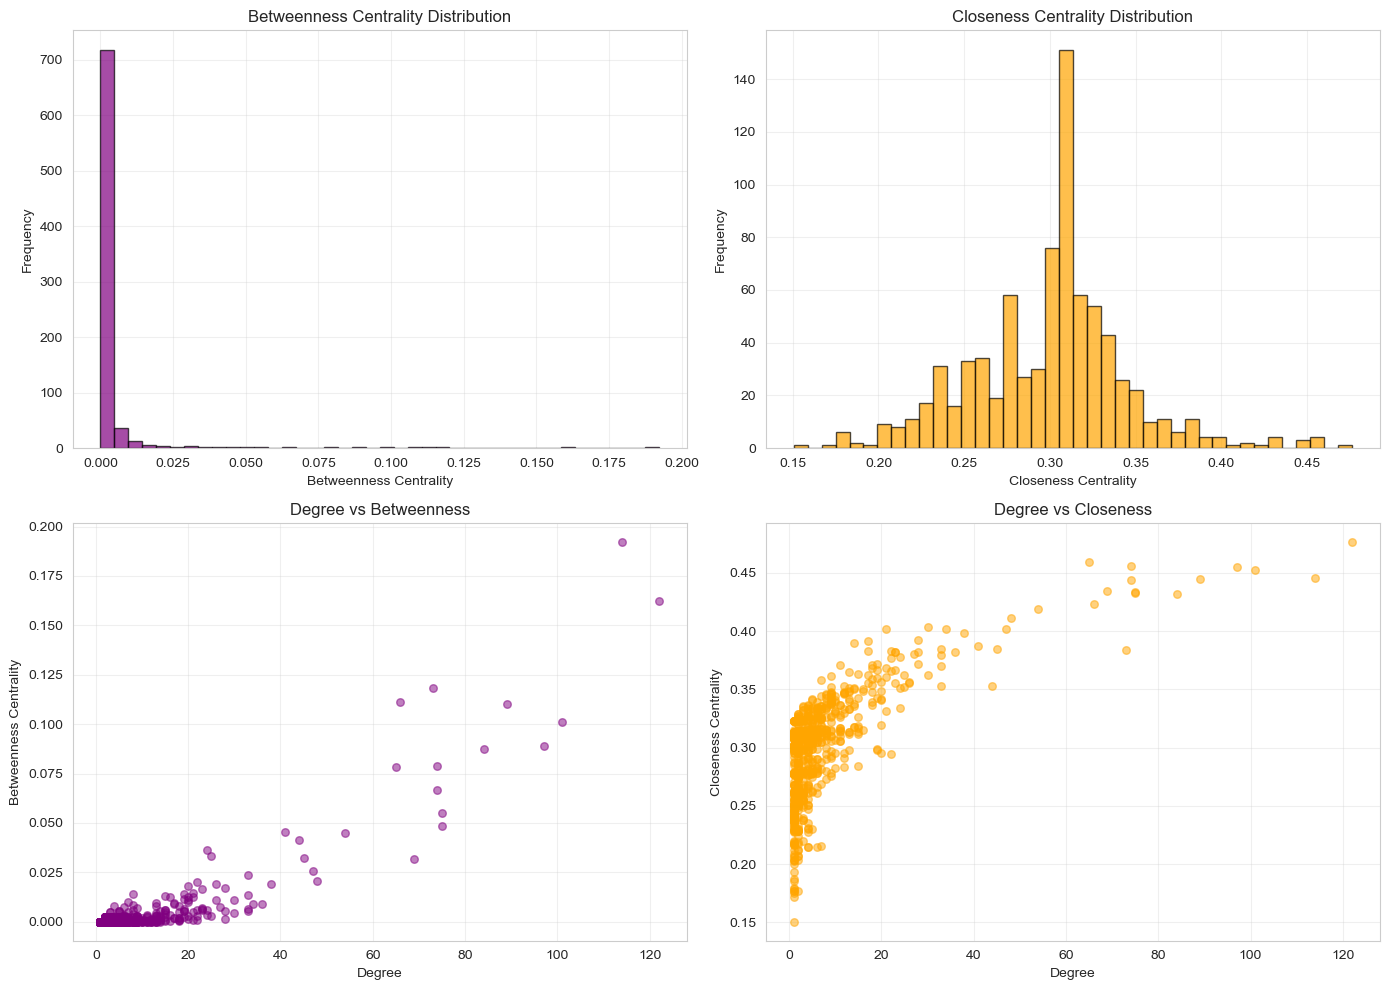

In [10]:
# 3. CENTRALITY ANALYSIS - Local Influence
# Different centrality measures capture different aspects of node importance

print("=" * 60)
print("LOCAL CENTRALITY MEASURES (Node-level Importance)")
print("=" * 60)
print()

# Betweenness centrality (how often a node is on shortest paths between others)
print("Computing betweenness centrality (this may take a moment)...")
betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by betweenness centrality (bridges):")
for node, cent in top_betweenness:
    print(f"  Node {node} ({get_node_name(node)}): {cent:.4f} (degree: {degree_dict[node]})")
print()

# Closeness centrality (average distance to all other nodes)
print("Computing closeness centrality...")
closeness = nx.closeness_centrality(G)
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by closeness centrality (central position):")
for node, cent in top_closeness:
    print(f"  Node {node} ({get_node_name(node)}): {cent:.4f} (degree: {degree_dict[node]})")
print()

# Eigenvector centrality (importance through high-centrality neighbors)
print("Computing eigenvector centrality...")
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
    top_eigenvector = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 nodes by eigenvector centrality (important neighborhoods):")
    for node, cent in top_eigenvector:
        print(f"  Node {node} ({get_node_name(node)}): {cent:.4f} (degree: {degree_dict[node]})")
except:
    print("Eigenvector centrality: Convergence issue (network may have isolated components)")
    eigenvector = None
print()

# Compare centrality measures
print("Centrality measure statistics:")
print(f"Betweenness: min={min(betweenness.values()):.4f}, max={max(betweenness.values()):.4f}, mean={np.mean(list(betweenness.values())):.4f}")
print(f"Closeness:   min={min(closeness.values()):.4f}, max={max(closeness.values()):.4f}, mean={np.mean(list(closeness.values())):.4f}")
if eigenvector:
    print(f"Eigenvector: min={min(eigenvector.values()):.4f}, max={max(eigenvector.values()):.4f}, mean={np.mean(list(eigenvector.values())):.4f}")
print()

# Visualize centrality measures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Betweenness histogram
axes[0, 0].hist(list(betweenness.values()), bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Betweenness Centrality')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Betweenness Centrality Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Closeness histogram
axes[0, 1].hist(list(closeness.values()), bins=40, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Closeness Centrality')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Closeness Centrality Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Degree vs Betweenness
axes[1, 0].scatter([degree_dict[n] for n in G.nodes()], 
                   [betweenness[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='purple')
axes[1, 0].set_xlabel('Degree')
axes[1, 0].set_ylabel('Betweenness Centrality')
axes[1, 0].set_title('Degree vs Betweenness')
axes[1, 0].grid(True, alpha=0.3)

# Degree vs Closeness
axes[1, 1].scatter([degree_dict[n] for n in G.nodes()], 
                   [closeness[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='orange')
axes[1, 1].set_xlabel('Degree')
axes[1, 1].set_ylabel('Closeness Centrality')
axes[1, 1].set_title('Degree vs Closeness')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 5. Comprehensive Microscale Summary

In [11]:
# 5. COMPREHENSIVE MICROSCALE SUMMARY
# Summary of all microscale measures computed

import pandas as pd

print("=" * 80)
print("MICROSCALE ANALYSIS SUMMARY")
print("=" * 80)
print()

# Create a summary table
summary_data = {
    'Measure': [],
    'Value': [],
    'Interpretation': []
}

# 1. Degree measures
summary_data['Measure'].append('Average Degree')
summary_data['Value'].append(f"{np.mean(degrees):.2f}")
summary_data['Interpretation'].append('Typical local connectivity')

summary_data['Measure'].append('Degree Range')
summary_data['Value'].append(f"{min(degrees)} - {max(degrees)}")
summary_data['Interpretation'].append('Network connectivity spread')

summary_data['Measure'].append('Network Density')
summary_data['Value'].append(f"{nx.density(G):.4f}")
summary_data['Interpretation'].append('Fraction of possible edges present')

summary_data['Measure'].append('Degree Assortativity')
summary_data['Value'].append(f"{nx.degree_assortativity_coefficient(G):.4f}")
summary_data['Interpretation'].append('High-deg → High-deg connection tendency')

# 2. Clustering measures
summary_data['Measure'].append('Avg Clustering Coeff')
summary_data['Value'].append(f"{np.mean(list(clustering_coeff.values())):.4f}")
summary_data['Interpretation'].append('Average triadic closure (transitivity)')

summary_data['Measure'].append('Network Transitivity')
summary_data['Value'].append(f"{nx.transitivity(G):.4f}")
summary_data['Interpretation'].append('Global clustering coefficient')

summary_data['Measure'].append('Total Triangles')
summary_data['Value'].append(f"{sum(triangle_values) // 3}")
summary_data['Interpretation'].append('Number of 3-node cycles')

# 3. Centrality measures
summary_data['Measure'].append('Avg Betweenness')
summary_data['Value'].append(f"{np.mean(list(betweenness.values())):.4f}")
summary_data['Interpretation'].append('Average bridging importance')

summary_data['Measure'].append('Avg Closeness')
summary_data['Value'].append(f"{np.mean(list(closeness.values())):.4f}")
summary_data['Interpretation'].append('Average distance to all nodes')

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print()

# Create a table of top influential nodes
print("=" * 80)
print("TOP 10 INFLUENTIAL NODES (by degree)")
print("=" * 80)
print()

top_nodes_data = {
    'Node': [],
    'Character': [],
    'Degree': [],
    'Clustering': [],
    'Betweenness': [],
    'Closeness': [],
    'Avg Neighbor Deg': []
}

for node, degree in sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]:
    top_nodes_data['Node'].append(node)
    top_nodes_data['Character'].append(get_node_name(node))
    top_nodes_data['Degree'].append(degree)
    top_nodes_data['Clustering'].append(f"{clustering_coeff[node]:.4f}")
    top_nodes_data['Betweenness'].append(f"{betweenness[node]:.4f}")
    top_nodes_data['Closeness'].append(f"{closeness[node]:.4f}")
    top_nodes_data['Avg Neighbor Deg'].append(f"{avg_neighbor_degree[node]:.2f}")

df_top_nodes = pd.DataFrame(top_nodes_data)
print(df_top_nodes.to_string(index=False))
print()

# Key insights
print("=" * 80)
print("KEY MICROSCALE INSIGHTS")
print("=" * 80)
print()

print("1. DEGREE STRUCTURE:")
print(f"   - Network is relatively sparse (density: {nx.density(G):.4f})")
print(f"   - Average node has {np.mean(degrees):.1f} connections (out of {G.number_of_nodes()-1} possible)")
print(f"   - High heterogeneity: degree ranges from {min(degrees)} to {max(degrees)}")
print()

print("2. LOCAL CLUSTERING:")
print(f"   - Average clustering coefficient: {np.mean(list(clustering_coeff.values())):.4f}")
print(f"   - This indicates {'strong' if np.mean(list(clustering_coeff.values())) > 0.3 else 'weak'} local grouping")
print(f"   - {sum(1 for t in triangle_values if t > 0)} nodes participate in triangles")
print()

print("3. NODE ROLES:")
degree_node = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[0][0]
between_node = top_betweenness[0][0]
close_node = top_closeness[0][0]
print(f"   - Hub (highest degree): Node {degree_node} ({get_node_name(degree_node)}) with {degree_dict[degree_node]} connections")
print(f"   - Bridge (highest betweenness): Node {between_node} ({get_node_name(between_node)})")
print(f"   - Central (highest closeness): Node {close_node} ({get_node_name(close_node)})")
print()

MICROSCALE ANALYSIS SUMMARY

             Measure   Value                          Interpretation
      Average Degree    7.09              Typical local connectivity
        Degree Range 1 - 122             Network connectivity spread
     Network Density  0.0089      Fraction of possible edges present
Degree Assortativity -0.1154 High-deg → High-deg connection tendency
Avg Clustering Coeff  0.4859  Average triadic closure (transitivity)
Network Transitivity  0.2090           Global clustering coefficient
     Total Triangles    5655                 Number of 3-node cycles
     Avg Betweenness  0.0030             Average bridging importance
       Avg Closeness  0.2998           Average distance to all nodes

TOP 10 INFLUENTIAL NODES (by degree)

 Node         Character  Degree Clustering Betweenness Closeness Avg Neighbor Deg
   10  Tyrion-Lannister     122     0.0893      0.1622    0.4763            20.57
   59          Jon-Snow     114     0.0663      0.1921    0.4454            16

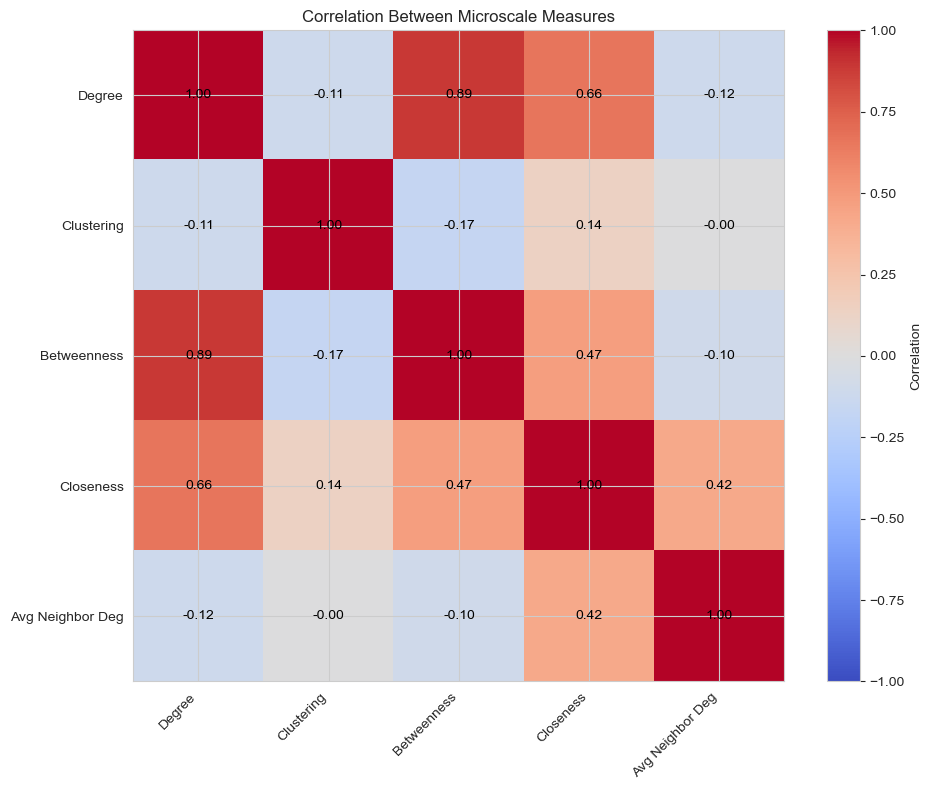


MEASURE CORRELATIONS

Correlation Matrix (how measures relate to each other):
                  Degree  Clustering  Betweenness  Closeness  Avg Neighbor Deg
Degree             1.000      -0.115        0.887      0.658            -0.115
Clustering        -0.115       1.000       -0.167      0.139            -0.000
Betweenness        0.887      -0.167        1.000      0.469            -0.096
Closeness          0.658       0.139        0.469      1.000             0.420
Avg Neighbor Deg  -0.115      -0.000       -0.096      0.420             1.000


In [12]:
# Create a heatmap showing correlation between different measures
fig, ax = plt.subplots(figsize=(10, 8))

# Get measures for all nodes
measures_matrix = np.array([
    [degree_dict[n] for n in G.nodes()],
    [clustering_coeff[n] for n in G.nodes()],
    [betweenness[n] for n in G.nodes()],
    [closeness[n] for n in G.nodes()],
    [avg_neighbor_degree[n] for n in G.nodes()]
])

# Normalize for better visualization
measures_normalized = (measures_matrix - measures_matrix.min(axis=1, keepdims=True)) / \
                      (measures_matrix.max(axis=1, keepdims=True) - measures_matrix.min(axis=1, keepdims=True))

# Correlation matrix
corr_matrix = np.corrcoef(measures_normalized)

# Plot heatmap
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(5))
ax.set_yticks(range(5))
measure_names = ['Degree', 'Clustering', 'Betweenness', 'Closeness', 'Avg Neighbor Deg']
ax.set_xticklabels(measure_names, rotation=45, ha='right')
ax.set_yticklabels(measure_names)

# Add correlation values
for i in range(5):
    for j in range(5):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=10)

ax.set_title('Correlation Between Microscale Measures')
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("MEASURE CORRELATIONS")
print("=" * 80)
print("\nCorrelation Matrix (how measures relate to each other):")
print(pd.DataFrame(corr_matrix, 
                   index=measure_names, 
                   columns=measure_names).round(3))


## 6. Advanced Centrality Measures (PageRank & Katz)

ADVANCED CENTRALITY MEASURES

Computing PageRank centrality...
Top 10 nodes by PageRank centrality (recursive importance):
  Node 59 (Jon-Snow): 0.035694 (degree: 114)
  Node 10 (Tyrion-Lannister): 0.032849 (degree: 122)
  Node 2 (Cersei-Lannister): 0.023607 (degree: 97)
  Node 19 (Daenerys-Targaryen): 0.022307 (degree: 73)
  Node 4 (Jaime-Lannister): 0.019754 (degree: 101)
  Node 20 (Eddard-Stark): 0.018938 (degree: 74)
  Node 68 (Arya-Stark): 0.018539 (degree: 84)
  Node 24 (Stannis-Baratheon): 0.018052 (degree: 89)
  Node 6 (Joffrey-Baratheon): 0.017420 (degree: 69)
  Node 15 (Robb-Stark): 0.017345 (degree: 74)

Computing Katz centrality...
Katz centrality: Convergence issue with default parameters

Computing edge betweenness centrality...
Top 10 edges by betweenness centrality (critical links):
  Edge (10 (Tyrion-Lannister), 59 (Jon-Snow)): 0.023347
  Edge (10 (Tyrion-Lannister), 19 (Daenerys-Targaryen)): 0.021806
  Edge (19 (Daenerys-Targaryen), 20 (Eddard-Stark)): 0.021350
  Edge

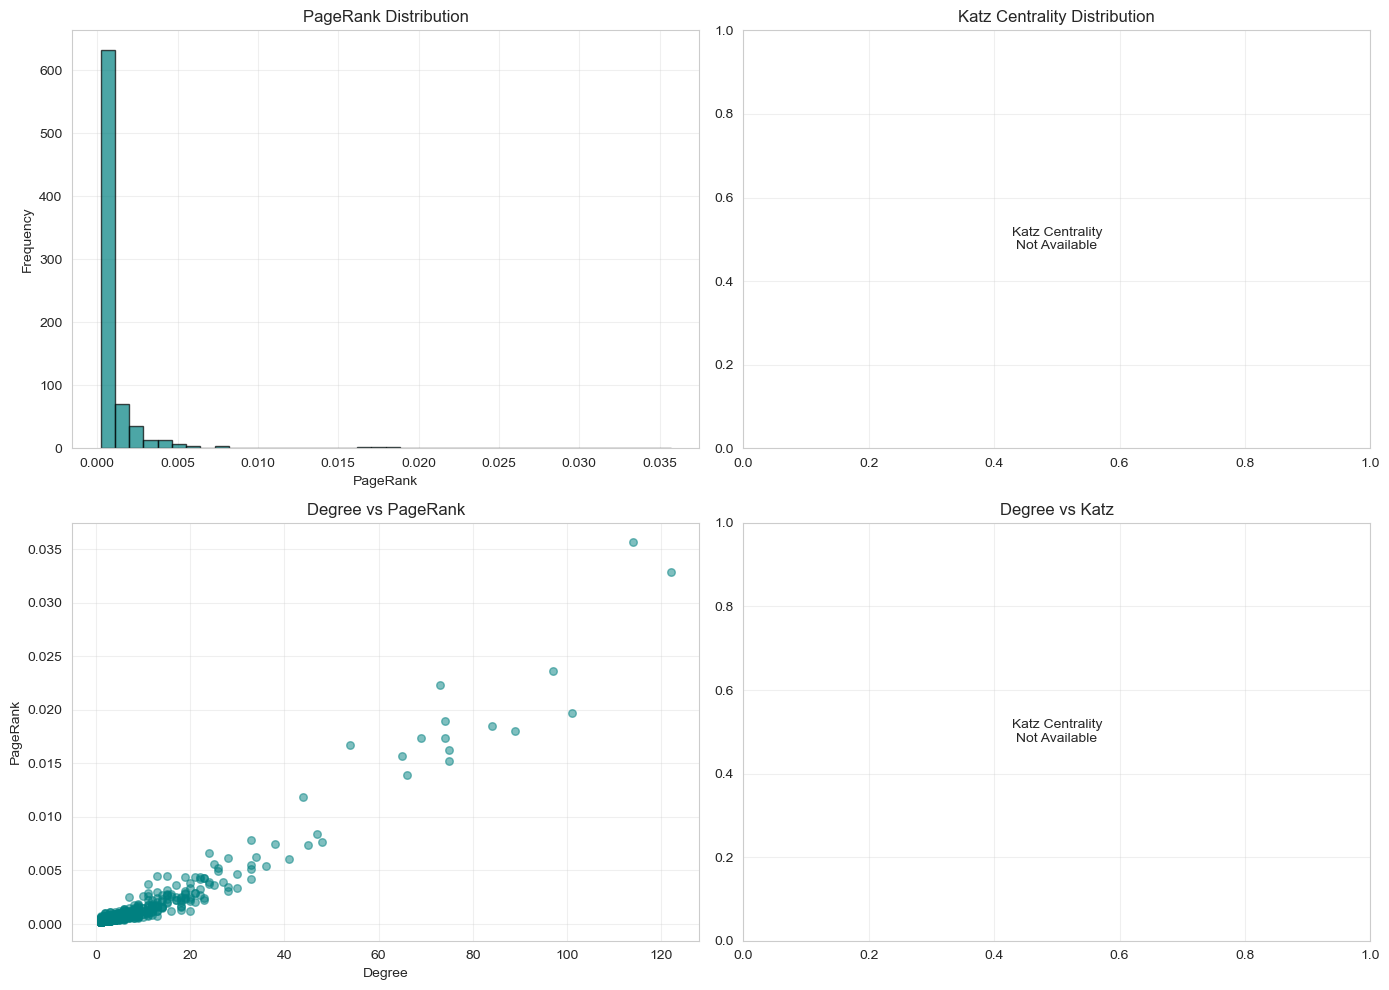

In [13]:
# 6. ADVANCED CENTRALITY MEASURES
# PageRank and Katz Centrality - Generalization of degree and eigenvector centrality

print("=" * 80)
print("ADVANCED CENTRALITY MEASURES")
print("=" * 80)
print()

# PageRank: Stationary probability of random walker following links with occasional jumps
print("Computing PageRank centrality...")
pagerank = nx.pagerank(G, max_iter=100000, tol=1e-6)
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by PageRank centrality (recursive importance):")
for node, rank in top_pagerank:
    print(f"  Node {node} ({get_node_name(node)}): {rank:.6f} (degree: {degree_dict[node]})")
print()

# Katz Centrality: Considers longer paths, attenuated by a factor
print("Computing Katz centrality...")
try:
    katz = nx.katz_centrality(G, max_iter=100000, tol=1e-6)
    top_katz = sorted(katz.items(), key=lambda x: x[1], reverse=True)[:10]
    print("Top 10 nodes by Katz centrality (recursive with path attenuation):")
    for node, cent in top_katz:
        print(f"  Node {node} ({get_node_name(node)}): {cent:.6f} (degree: {degree_dict[node]})")
except:
    print("Katz centrality: Convergence issue with default parameters")
    katz = None
print()

# Edge Betweenness: How often an edge lies on shortest paths
print("Computing edge betweenness centrality...")
edge_betweenness = nx.edge_betweenness_centrality(G)
top_edges = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 edges by betweenness centrality (critical links):")
for (u, v), betweenness_val in top_edges:
    print(f"  Edge ({u} ({get_node_name(u)}), {v} ({get_node_name(v)})): {betweenness_val:.6f}")
print()

# Statistics for advanced centrality measures
print("Centrality measure statistics:")
print(f"PageRank:      min={min(pagerank.values()):.6f}, max={max(pagerank.values()):.6f}, mean={np.mean(list(pagerank.values())):.6f}")
if katz:
    print(f"Katz:          min={min(katz.values()):.6f}, max={max(katz.values()):.6f}, mean={np.mean(list(katz.values())):.6f}")
print(f"Edge Between:  min={min(edge_betweenness.values()):.6f}, max={max(edge_betweenness.values()):.6f}, mean={np.mean(list(edge_betweenness.values())):.6f}")
print()

# Visualize advanced centrality measures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PageRank histogram
axes[0, 0].hist(list(pagerank.values()), bins=40, color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('PageRank')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PageRank Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Katz histogram
if katz:
    axes[0, 1].hist(list(katz.values()), bins=40, color='olive', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Katz Centrality')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Katz Centrality Distribution')
else:
    axes[0, 1].text(0.5, 0.5, 'Katz Centrality\nNot Available', 
                    ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Katz Centrality Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Degree vs PageRank
axes[1, 0].scatter([degree_dict[n] for n in G.nodes()], 
                   [pagerank[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='teal')
axes[1, 0].set_xlabel('Degree')
axes[1, 0].set_ylabel('PageRank')
axes[1, 0].set_title('Degree vs PageRank')
axes[1, 0].grid(True, alpha=0.3)

# Degree vs Katz (if available)
if katz:
    axes[1, 1].scatter([degree_dict[n] for n in G.nodes()], 
                       [katz[n] for n in G.nodes()], 
                       alpha=0.5, s=30, color='olive')
    axes[1, 1].set_xlabel('Degree')
    axes[1, 1].set_ylabel('Katz Centrality')
    axes[1, 1].set_title('Degree vs Katz')
else:
    axes[1, 1].text(0.5, 0.5, 'Katz Centrality\nNot Available', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Degree vs Katz')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 7. Shortest Paths & Distance Analysis

SHORTEST PATHS & DISTANCE ANALYSIS

Basic distance metrics:
Network diameter (longest shortest path): 9
Average shortest path length: 3.4162

Computing eccentricity (max distance from each node)...
Eccentricity range: 5 - 9
Average eccentricity: 6.77

Network center (nodes with minimum eccentricity=5):
  Node 15 (Robb-Stark)
  Node 24 (Stannis-Baratheon)
  Node 41 (Aemon-Targaryen-(Maester-Aemon))
  Node 44 (Alliser-Thorne)
  Node 57 (Janos-Slynt)
  Node 58 (Jeor-Mormont)
  Node 59 (Jon-Snow)
  Node 64 (Robert-Baratheon)
  Node 120 (Bran-Stark)
  Node 243 (Randyll-Tarly)

Peripheral nodes (nodes with maximum eccentricity=9):
  Node 449 (Lucifer-Long)
  Node 581 (Hugh-Hungerford)
  Node 631 (Murch)
  Node 640 (Gerold-Grafton)
  Node 646 (Gormon-Tyrell)
  Node 736 (Torwold-Browntooth)
  Node 743 (Manfrey-Martell)
  Node 787 (Simon-Toyne)

Network radius: 5
Network diameter: 9

Analyzing shortest paths from hub node 10 (Tyrion-Lannister):
  Distance distribution from node 10:
    Distance

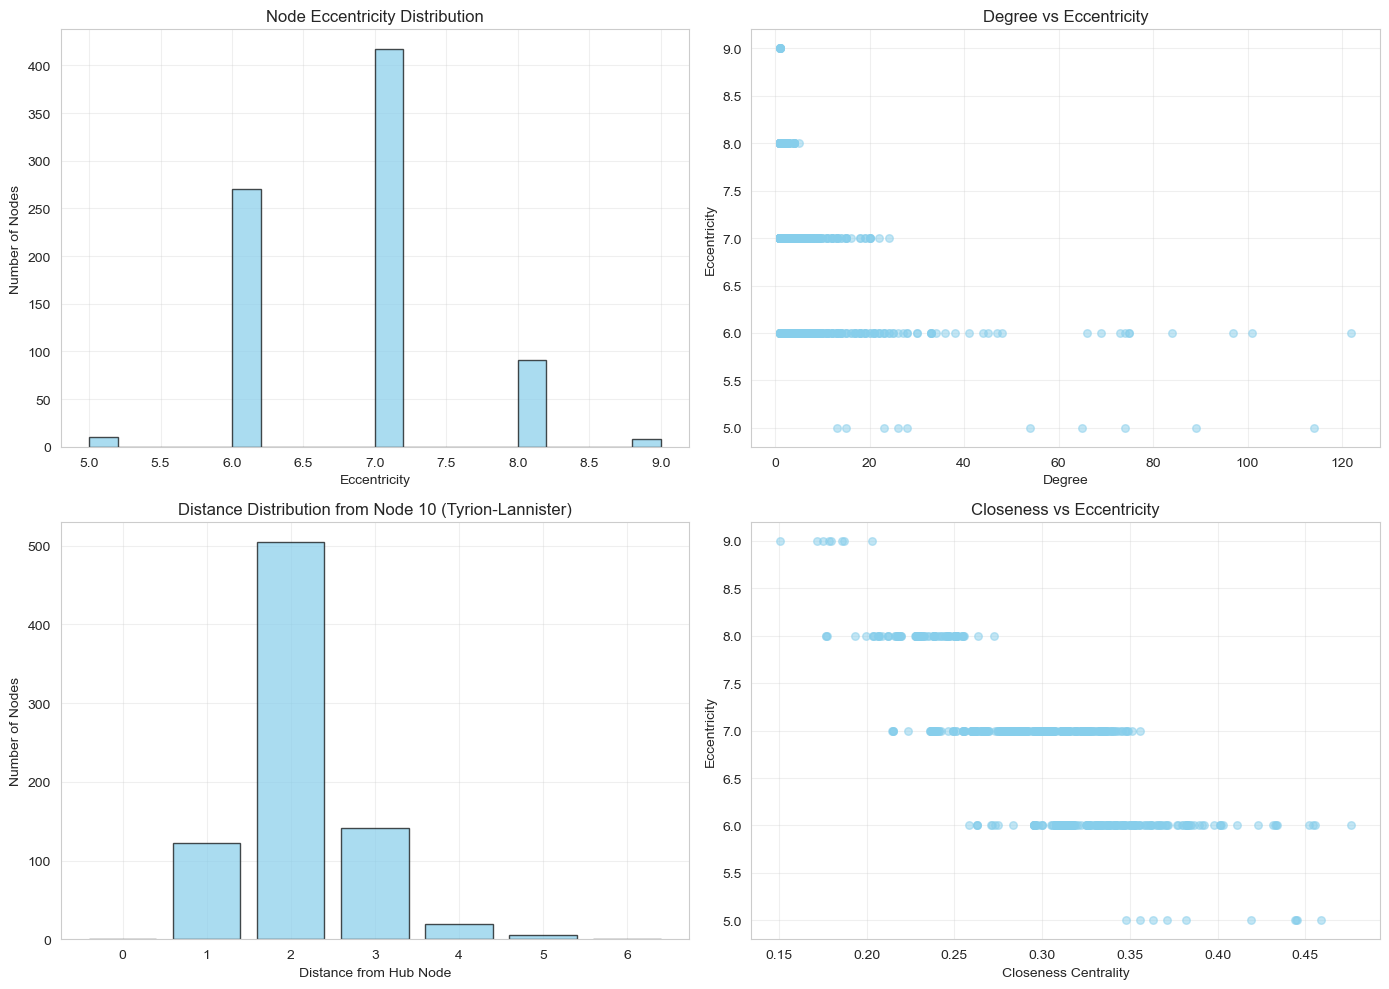

In [14]:
# 7. SHORTEST PATHS & DISTANCE ANALYSIS
# Distance-based metrics: diameter, average distance, eccentricity

print("=" * 80)
print("SHORTEST PATHS & DISTANCE ANALYSIS")
print("=" * 80)
print()

# Basic distance metrics
print("Basic distance metrics:")
print(f"Network diameter (longest shortest path): {nx.diameter(G)}")
print(f"Average shortest path length: {nx.average_shortest_path_length(G):.4f}")
print()

# Eccentricity: Maximum distance from a node to any other node
print("Computing eccentricity (max distance from each node)...")
eccentricity = nx.eccentricity(G)
ecc_values = list(eccentricity.values())
print(f"Eccentricity range: {min(ecc_values)} - {max(ecc_values)}")
print(f"Average eccentricity: {np.mean(ecc_values):.2f}")
print()

# Nodes with minimum eccentricity (centers)
min_ecc = min(ecc_values)
center_nodes = [node for node, ecc in eccentricity.items() if ecc == min_ecc]
print(f"Network center (nodes with minimum eccentricity={min_ecc}):")
for node in center_nodes[:10]:
    print(f"  Node {node} ({get_node_name(node)})")
print()

# Peripheral nodes (maximum eccentricity)
max_ecc = max(ecc_values)
peripheral_nodes = [node for node, ecc in eccentricity.items() if ecc == max_ecc]
print(f"Peripheral nodes (nodes with maximum eccentricity={max_ecc}):")
for node in peripheral_nodes[:10]:
    print(f"  Node {node} ({get_node_name(node)})")
print()

# Radius and diameter interpretation
radius = nx.radius(G)
diameter = nx.diameter(G)
print(f"Network radius: {radius}")
print(f"Network diameter: {diameter}")
print()

# Analyze shortest paths from high-degree node
sample_node = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[0][0]
print(f"Analyzing shortest paths from hub node {sample_node} ({get_node_name(sample_node)}):")

# Get all shortest paths from sample node
path_lengths = nx.single_source_shortest_path_length(G, sample_node)
path_length_values = list(path_lengths.values())
print(f"  Distance distribution from node {sample_node}:")
for dist in sorted(set(path_length_values)):
    count = sum(1 for d in path_length_values if d == dist)
    print(f"    Distance {dist}: {count} nodes")
print()

# Visualize distance distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Eccentricity histogram
axes[0, 0].hist(ecc_values, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Eccentricity')
axes[0, 0].set_ylabel('Number of Nodes')
axes[0, 0].set_title('Node Eccentricity Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Degree vs Eccentricity
axes[0, 1].scatter([degree_dict[n] for n in G.nodes()], 
                   [eccentricity[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='skyblue')
axes[0, 1].set_xlabel('Degree')
axes[0, 1].set_ylabel('Eccentricity')
axes[0, 1].set_title('Degree vs Eccentricity')
axes[0, 1].grid(True, alpha=0.3)

# Distance distribution from hub node
dist_counts = {}
for dist in path_length_values:
    dist_counts[dist] = dist_counts.get(dist, 0) + 1

axes[1, 0].bar(dist_counts.keys(), dist_counts.values(), color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Distance from Hub Node')
axes[1, 0].set_ylabel('Number of Nodes')
axes[1, 0].set_title(f'Distance Distribution from Node {sample_node} ({get_node_name(sample_node)})')
axes[1, 0].grid(True, alpha=0.3)

# Closeness vs Eccentricity correlation
axes[1, 1].scatter([closeness[n] for n in G.nodes()], 
                   [eccentricity[n] for n in G.nodes()], 
                   alpha=0.5, s=30, color='skyblue')
axes[1, 1].set_xlabel('Closeness Centrality')
axes[1, 1].set_ylabel('Eccentricity')
axes[1, 1].set_title('Closeness vs Eccentricity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 8. Matrix Analysis (Adjacency & Laplacian)

MATRIX ANALYSIS

ADJACENCY MATRIX ANALYSIS:
--------------------------------------------------------------------------------
Adjacency matrix shape: (796, 796)
Adjacency matrix non-zero elements: 5646
Matrix density: 0.008911

Computing principal eigenvector of adjacency matrix...
Largest eigenvalue: 953.787369
Smallest eigenvalue: -401.886400

Top 10 nodes by principal eigenvector (most important by adjacency structure):
  Node 10 (Tyrion-Lannister): 0.380524 (degree: 122)
  Node 2 (Cersei-Lannister): 0.358753 (degree: 97)
  Node 6 (Joffrey-Baratheon): 0.343004 (degree: 69)
  Node 64 (Robert-Baratheon): 0.282702 (degree: 65)
  Node 20 (Eddard-Stark): 0.281760 (degree: 74)
  Node 138 (Sansa-Stark): 0.274303 (degree: 75)
  Node 4 (Jaime-Lannister): 0.214832 (degree: 101)
  Node 15 (Robb-Stark): 0.173973 (degree: 74)
  Node 59 (Jon-Snow): 0.169016 (degree: 114)
  Node 14 (Catelyn-Stark): 0.164057 (degree: 75)

LAPLACIAN MATRIX ANALYSIS:
---------------------------------------------------

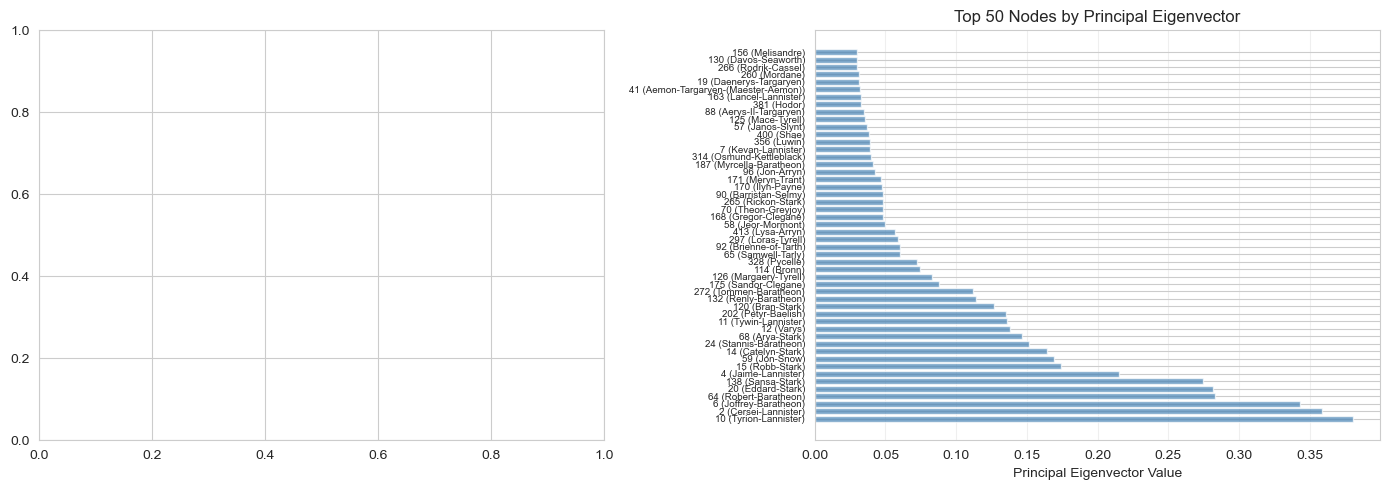

In [15]:
# 8. MATRIX ANALYSIS - Adjacency and Laplacian Matrices

from scipy import sparse
from scipy.sparse import linalg

print("=" * 80)
print("MATRIX ANALYSIS")
print("=" * 80)
print()

# ===== ADJACENCY MATRIX =====
print("ADJACENCY MATRIX ANALYSIS:")
print("-" * 80)

# Convert graph to adjacency matrix (sparse)
adj_matrix = nx.adjacency_matrix(G)
print(f"Adjacency matrix shape: {adj_matrix.shape}")
print(f"Adjacency matrix non-zero elements: {adj_matrix.nnz}")
print(f"Matrix density: {adj_matrix.nnz / (adj_matrix.shape[0] * adj_matrix.shape[1]):.6f}")
print()

# Principal eigenvector of adjacency matrix
print("Computing principal eigenvector of adjacency matrix...")
try:
    # Get the largest eigenvalue and its eigenvector
    eigenvalues, eigenvectors = sparse.linalg.eigsh(adj_matrix, k=6, which='LM', return_eigenvectors=True)
    
    # The largest eigenvalue is the last one
    largest_eigenvalue = eigenvalues[-1]
    principal_eigenvector = eigenvectors[:, -1]
    
    print(f"Largest eigenvalue: {largest_eigenvalue:.6f}")
    print(f"Smallest eigenvalue: {eigenvalues[0]:.6f}")
    print()
    
    # Principal eigenvector identifies most important node
    principal_eigenvector_abs = np.abs(principal_eigenvector)
    most_important_nodes = np.argsort(principal_eigenvector_abs)[-10:][::-1]
    
    print("Top 10 nodes by principal eigenvector (most important by adjacency structure):")
    node_list = list(G.nodes())
    for idx, node_idx in enumerate(most_important_nodes):
        node = node_list[node_idx]
        print(f"  Node {node} ({get_node_name(node)}): {principal_eigenvector_abs[node_idx]:.6f} (degree: {degree_dict[node]})")
    print()
    
except Exception as e:
    print(f"Eigenvalue computation error: {e}")
    print()

# ===== LAPLACIAN MATRIX =====
print("LAPLACIAN MATRIX ANALYSIS:")
print("-" * 80)

# Laplacian matrix
laplacian_matrix = nx.laplacian_matrix(G)
print(f"Laplacian matrix shape: {laplacian_matrix.shape}")
print()

# Eigenvalues of Laplacian
print("Computing Laplacian eigenvalues...")
try:
    # Get smallest eigenvalues (sparse is better for this)
    lap_eigenvalues, _ = sparse.linalg.eigsh(laplacian_matrix, k=10, which='SM', return_eigenvectors=False)
    
    print(f"Smallest 10 Laplacian eigenvalues:")
    for i, eig in enumerate(sorted(lap_eigenvalues)):
        print(f"  λ{i}: {eig:.6f}")
    print()
    
    # Count zero eigenvalues (connected components)
    num_zeros = sum(1 for eig in lap_eigenvalues if abs(eig) < 1e-6)
    print(f"Approximate number of zero eigenvalues (connected components): {num_zeros}")
    print(f"Actual connected components: {nx.number_connected_components(G)}")
    print()
    
    # Algebraic connectivity (second smallest eigenvalue)
    if len(lap_eigenvalues) > 1:
        algebraic_connectivity = sorted(lap_eigenvalues)[1]
        print(f"Algebraic connectivity (2nd smallest eigenvalue): {algebraic_connectivity:.6f}")
        print("  (Measures how well-connected the graph is)")
    print()
    
except Exception as e:
    print(f"Laplacian eigenvalue computation error: {e}")
    print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot eigenvalues
if 'lap_eigenvalues' in locals():
    sorted_lap_eigs = sorted(lap_eigenvalues)
    axes[0].plot(range(len(sorted_lap_eigs)), sorted_lap_eigs, 'o-', color='darkred', linewidth=2, markersize=6)
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Eigenvalue')
    axes[0].set_title('Sorted Laplacian Eigenvalues (Spectral Analysis)')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Principal eigenvector visualization
if 'principal_eigenvector_abs' in locals():
    top_eig_indices = np.argsort(principal_eigenvector_abs)[-50:][::-1]
    node_list = list(G.nodes())
    top_nodes = [node_list[i] for i in top_eig_indices]
    top_values = principal_eigenvector_abs[top_eig_indices]
    top_names = [get_node_name(n) for n in top_nodes]
    
    axes[1].barh(range(len(top_values)), top_values, color='steelblue', alpha=0.7)
    axes[1].set_yticks(range(len(top_values)))
    axes[1].set_yticklabels([f"{n} ({name})" for n, name in zip(top_nodes, top_names)], fontsize=7)
    axes[1].set_xlabel('Principal Eigenvector Value')
    axes[1].set_title('Top 50 Nodes by Principal Eigenvector')
    axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print()

## Macroscale

## 1. Connected Components & Connectedness

In [9]:
# 1. CONNECTED COMPONENTS & CONNECTEDNESS

print("=" * 80)
print("CONNECTED COMPONENTS ANALYSIS")
print("=" * 80)
print()

# Analyze connected components
num_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Number of connected components: {num_components}")
print(f"Largest component size: {component_sizes[0]} nodes ({100*component_sizes[0]/G.number_of_nodes():.1f}%)")
print(f"Component sizes (top 10): {component_sizes[:10]}")
print()

# Main component analysis
main_component = max(nx.connected_components(G), key=len)
G_main = G.subgraph(main_component).copy()

print(f"MAIN COMPONENT STATISTICS:")
print(f"  Nodes: {G_main.number_of_nodes()}")
print(f"  Edges: {G_main.number_of_edges()}")
print(f"  Density: {nx.density(G_main):.4f}")
print()

# For the main component, compute global distance metrics
if nx.is_connected(G_main):
    diameter = nx.diameter(G_main)
    radius = nx.radius(G_main)
    avg_shortest_path = nx.average_shortest_path_length(G_main)
    
    print("GLOBAL DISTANCE METRICS (Main Component):")
    print(f"  Network diameter: {diameter}")
    print(f"  Network radius: {radius}")
    print(f"  Average shortest path length: {avg_shortest_path:.4f}")
    print()
    
    # Small-world analysis
    print("SMALL-WORLD PROPERTY:")
    print(f"  Expected diameter (random network): ~ln(N)/ln(<k>) = ln({G_main.number_of_nodes()})/ln({2*G_main.number_of_edges()/G_main.number_of_nodes():.2f}) = {np.log(G_main.number_of_nodes())/np.log(2*G_main.number_of_edges()/G_main.number_of_nodes()):.2f}")
    print(f"  Actual diameter / Expected: {diameter} / {np.log(G_main.number_of_nodes())/np.log(2*G_main.number_of_edges()/G_main.number_of_nodes()):.2f} ratio = {diameter / (np.log(G_main.number_of_nodes())/np.log(2*G_main.number_of_edges()/G_main.number_of_nodes())):.2f}")
    print(f"  Average path length: {avg_shortest_path:.4f}")
    print(f"  Expected if random: {np.log(G_main.number_of_nodes())/np.log(2*G_main.number_of_edges()/G_main.number_of_nodes()):.4f}")
    print()
else:
    print("Network is disconnected. Using largest component for distance metrics.")
    print()

# Eccentricity analysis for entire graph
eccentricity = nx.eccentricity(G_main)
ecc_values = list(eccentricity.values())

print("ECCENTRICITY ANALYSIS:")
print(f"  Center (min eccentricity) nodes: {nx.center(G_main)}")
print(f"  Periphery (max eccentricity) nodes: {len(nx.periphery(G_main))} nodes")
print(f"  Average eccentricity: {np.mean(ecc_values):.2f}")
print()

CONNECTED COMPONENTS ANALYSIS

Number of connected components: 1
Largest component size: 796 nodes (100.0%)
Component sizes (top 10): [796]

MAIN COMPONENT STATISTICS:
  Nodes: 796
  Edges: 2823
  Density: 0.0089

GLOBAL DISTANCE METRICS (Main Component):
  Network diameter: 9
  Network radius: 5
  Average shortest path length: 3.4162

SMALL-WORLD PROPERTY:
  Expected diameter (random network): ~ln(N)/ln(<k>) = ln(796)/ln(7.09) = 3.41
  Actual diameter / Expected: 9 / 3.41 ratio = 2.64
  Average path length: 3.4162
  Expected if random: 3.4095

ECCENTRICITY ANALYSIS:
  Center (min eccentricity) nodes: [15, 24, 41, 44, 57, 58, 59, 64, 120, 243]
  Periphery (max eccentricity) nodes: 8 nodes
  Average eccentricity: 6.77



## 2. Degree Distribution & Power-Law Analysis

DEGREE DISTRIBUTION ANALYSIS

DEGREE DISTRIBUTION STATISTICS:
  Min degree: 1
  Max degree: 122
  Mean degree: 7.09
  Median degree: 3.00
  Std dev degree: 12.68
  Skewness: 4.9957
  Kurtosis: 30.7854

POWER-LAW ANALYSIS (Log-Log Binning):
  Estimated exponent (γ): 1.9477
  (Network is scale-free if 2 < γ < 3)



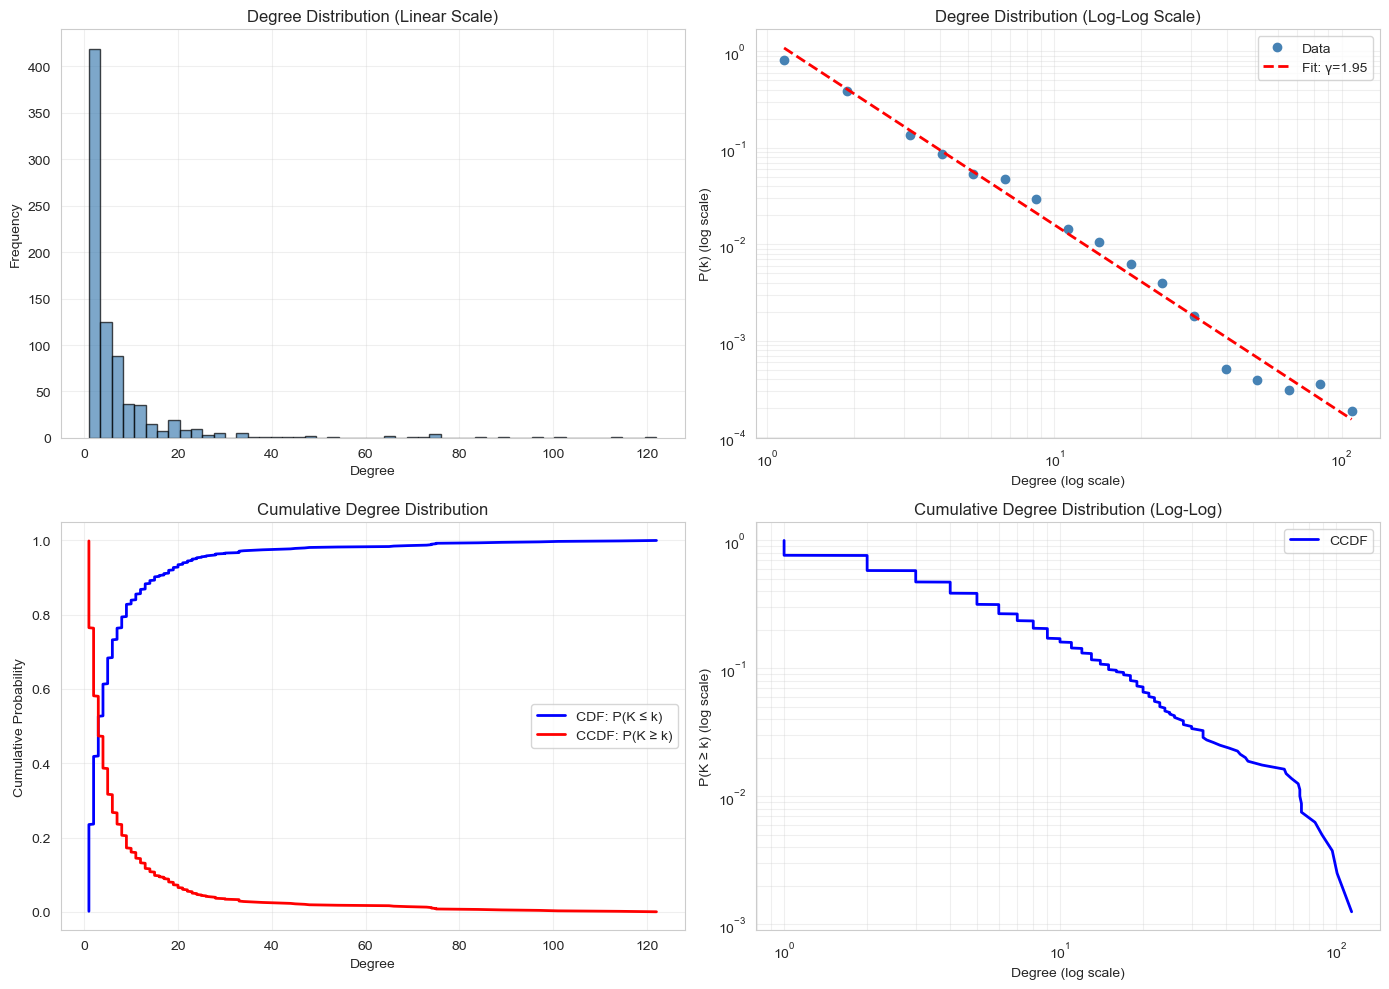

In [10]:
# 2. DEGREE DISTRIBUTION & POWER-LAW ANALYSIS

print("=" * 80)
print("DEGREE DISTRIBUTION ANALYSIS")
print("=" * 80)
print()

# Use main component for consistent analysis
degrees_main = [G_main.degree(n) for n in G_main.nodes()]

print("DEGREE DISTRIBUTION STATISTICS:")
print(f"  Min degree: {min(degrees_main)}")
print(f"  Max degree: {max(degrees_main)}")
print(f"  Mean degree: {np.mean(degrees_main):.2f}")
print(f"  Median degree: {np.median(degrees_main):.2f}")
print(f"  Std dev degree: {np.std(degrees_main):.2f}")
print(f"  Skewness: {pd.Series(degrees_main).skew():.4f}")
print(f"  Kurtosis: {pd.Series(degrees_main).kurtosis():.4f}")
print()

# Cumulative degree distribution (CDF)
sorted_degrees = sorted(degrees_main)
cdf = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)

# Complementary CDF (CCDF): P(k >= k_i)
ccdf = 1 - cdf

# Degree distribution P(k) using binning
degree_counts = {}
for d in degrees_main:
    degree_counts[d] = degree_counts.get(d, 0) + 1

pk = {k: count / len(degrees_main) for k, count in degree_counts.items()}

# Power-law fitting (log-log analysis)
# Using exponentially-spaced bins for better power-law fit
log_bins = np.logspace(np.log10(max(1, min(degrees_main))), np.log10(max(degrees_main)), 20)
hist_counts, bin_edges = np.histogram(degrees_main, bins=log_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
hist_prob = hist_counts / (len(degrees_main) * np.diff(bin_edges))

# Remove zero bins for log-log fit
nonzero_mask = hist_counts > 0
nonzero_centers = bin_centers[nonzero_mask]
nonzero_prob = hist_prob[nonzero_mask]

# Linear regression on log-log scale to estimate exponent
if len(nonzero_centers) > 2:
    log_x = np.log(nonzero_centers)
    log_y = np.log(nonzero_prob)
    
    # Fit line: log(P) = -α * log(k) + b
    coeffs = np.polyfit(log_x, log_y, 1)
    alpha = -coeffs[0]  # The exponent γ is -slope
    
    print("POWER-LAW ANALYSIS (Log-Log Binning):")
    print(f"  Estimated exponent (γ): {alpha:.4f}")
    print(f"  (Network is scale-free if 2 < γ < 3)")
    print()

# Visualize degree distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear scale histogram
axes[0, 0].hist(degrees_main, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Degree')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Degree Distribution (Linear Scale)')
axes[0, 0].grid(True, alpha=0.3)

# Log-log histogram
axes[0, 1].loglog(nonzero_centers, nonzero_prob, 'o', color='steelblue', markersize=6, label='Data')
if len(nonzero_centers) > 2:
    fit_line = np.exp(np.polyval(coeffs, log_x))
    axes[0, 1].loglog(nonzero_centers, fit_line, 'r--', linewidth=2, label=f'Fit: γ={alpha:.2f}')
    axes[0, 1].legend()
axes[0, 1].set_xlabel('Degree (log scale)')
axes[0, 1].set_ylabel('P(k) (log scale)')
axes[0, 1].set_title('Degree Distribution (Log-Log Scale)')
axes[0, 1].grid(True, alpha=0.3, which='both')

# CDF and CCDF
axes[1, 0].plot(sorted_degrees, cdf, 'b-', linewidth=2, label='CDF: P(K ≤ k)')
axes[1, 0].plot(sorted_degrees, ccdf, 'r-', linewidth=2, label='CCDF: P(K ≥ k)')
axes[1, 0].set_xlabel('Degree')
axes[1, 0].set_ylabel('Cumulative Probability')
axes[1, 0].set_title('Cumulative Degree Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Log-log CCDF (alternative power-law visualization)
# Remove zeros for log scale
ccdf_nonzero = ccdf[ccdf > 0]
degrees_nonzero = np.array(sorted_degrees)[ccdf > 0]

if len(degrees_nonzero) > 0:
    axes[1, 1].loglog(degrees_nonzero, ccdf_nonzero, 'b-', linewidth=2, label='CCDF')
    axes[1, 1].set_xlabel('Degree (log scale)')
    axes[1, 1].set_ylabel('P(K ≥ k) (log scale)')
    axes[1, 1].set_title('Cumulative Degree Distribution (Log-Log)')
    axes[1, 1].grid(True, alpha=0.3, which='both')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()
print()

## 3. Degree Correlations & Assortativity

DEGREE CORRELATIONS & ASSORTATIVITY

Degree Assortativity Coefficient (r): -0.1154

INTERPRETATION: DISASSORTATIVE NETWORK
  - High-degree nodes tend to connect with low-degree nodes
  - High-degree nodes act as 'hubs' bridging groups
  - Common in: Technological networks, scale-free networks

AVERAGE NEIGHBOR DEGREE ANALYSIS:
  Min avg neighbor degree: 2.00
  Max avg neighbor degree: 122.00
  Mean avg neighbor degree: 34.83

Average neighbor degree k_nn(k) by node degree:
Degree (k)   | k_nn(k)      | Trend          
---------------------------------------------
1            | 44.05        | -              
7            | 32.49        | ↓ Decreasing   
13           | 29.63        | ↓ Decreasing   
19           | 26.90        | ↓ Decreasing   
25           | 22.08        | ↓ Decreasing   
34           | 40.24        | ↑ Increasing   
47           | 33.40        | ↓ Decreasing   
73           | 13.26        | ↓ Decreasing   
101          | 21.55        | ↑ Increasing   



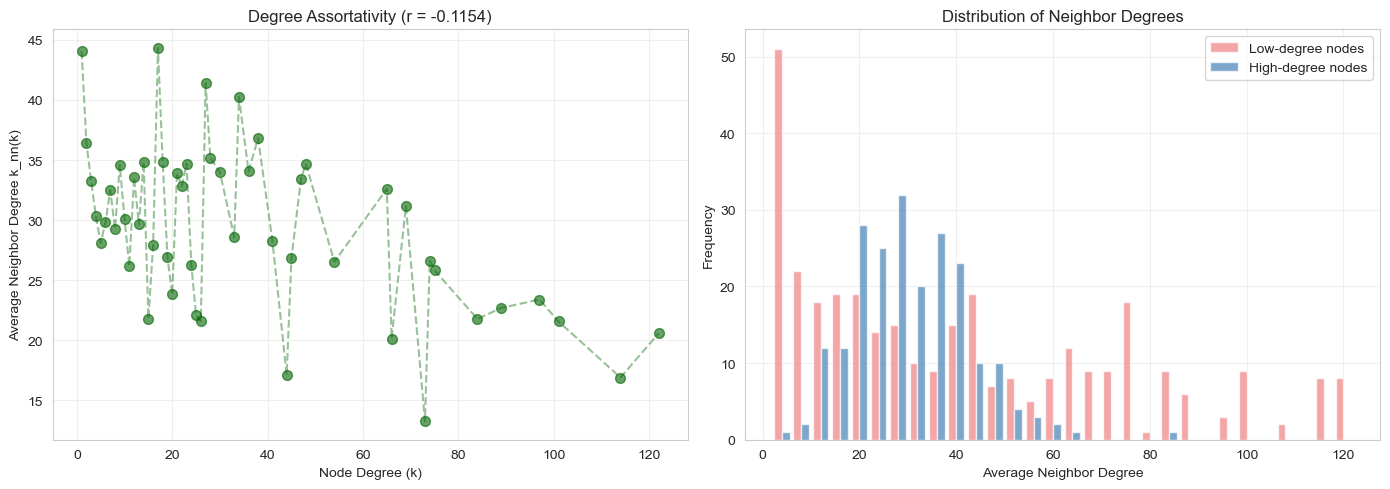

In [11]:
# 3. DEGREE CORRELATIONS & ASSORTATIVITY

print("=" * 80)
print("DEGREE CORRELATIONS & ASSORTATIVITY")
print("=" * 80)
print()

# Degree assortativity coefficient
assortativity = nx.degree_assortativity_coefficient(G_main)
print(f"Degree Assortativity Coefficient (r): {assortativity:.4f}")
print()

if assortativity > 0:
    print("INTERPRETATION: ASSORTATIVE NETWORK")
    print("  - High-degree nodes tend to connect with other high-degree nodes")
    print("  - Creates a hierarchical or 'club' structure")
    print("  - Common in: Social networks, biological networks")
elif assortativity < 0:
    print("INTERPRETATION: DISASSORTATIVE NETWORK")
    print("  - High-degree nodes tend to connect with low-degree nodes")
    print("  - High-degree nodes act as 'hubs' bridging groups")
    print("  - Common in: Technological networks, scale-free networks")
else:
    print("INTERPRETATION: NEUTRAL NETWORK")
    print("  - No significant degree correlation")
    print()

print()

# Average neighbor degree analysis
print("AVERAGE NEIGHBOR DEGREE ANALYSIS:")
avg_neighbor_degree_main = nx.average_neighbor_degree(G_main)
avg_nd_values = list(avg_neighbor_degree_main.values())

print(f"  Min avg neighbor degree: {min(avg_nd_values):.2f}")
print(f"  Max avg neighbor degree: {max(avg_nd_values):.2f}")
print(f"  Mean avg neighbor degree: {np.mean(avg_nd_values):.2f}")
print()

# Compute k_nn(k) = average neighbor degree as function of degree
degree_dict_main = dict(G_main.degree())
knn_by_degree = {}

for k in sorted(set(degree_dict_main.values())):
    nodes_with_degree_k = [n for n, deg in degree_dict_main.items() if deg == k]
    knn_values = [avg_neighbor_degree_main[n] for n in nodes_with_degree_k]
    knn_by_degree[k] = np.mean(knn_values) if knn_values else 0

print("Average neighbor degree k_nn(k) by node degree:")
print(f"{'Degree (k)':<12} | {'k_nn(k)':<12} | {'Trend':<15}")
print("-" * 45)

degrees_k = sorted(knn_by_degree.keys())
for i, k in enumerate(degrees_k[::max(1, len(degrees_k)//8)]):  # Show ~8 values
    knn = knn_by_degree[k]
    
    # Determine trend
    if i == 0:
        trend = "-"
    elif knn > prev_knn:
        trend = "↑ Increasing"
    elif knn < prev_knn:
        trend = "↓ Decreasing"
    else:
        trend = "→ Stable"
    
    print(f"{k:<12} | {knn:<12.2f} | {trend:<15}")
    prev_knn = knn

print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k_nn(k) plot
k_values = sorted(knn_by_degree.keys())
knn_values = [knn_by_degree[k] for k in k_values]

axes[0].scatter(k_values, knn_values, alpha=0.6, s=50, color='darkgreen')
if len(k_values) > 1:
    axes[0].plot(k_values, knn_values, '--', alpha=0.4, color='darkgreen')
axes[0].set_xlabel('Node Degree (k)')
axes[0].set_ylabel('Average Neighbor Degree k_nn(k)')
axes[0].set_title(f'Degree Assortativity (r = {assortativity:.4f})')
axes[0].grid(True, alpha=0.3)

# Distribution of neighbor degrees for high-degree vs low-degree nodes
high_degree_threshold = np.percentile(list(degree_dict_main.values()), 75)
low_degree_threshold = np.percentile(list(degree_dict_main.values()), 25)

high_deg_nodes = [n for n, d in degree_dict_main.items() if d >= high_degree_threshold]
low_deg_nodes = [n for n, d in degree_dict_main.items() if d <= low_degree_threshold]

high_deg_neighbor_degs = [avg_neighbor_degree_main[n] for n in high_deg_nodes]
low_deg_neighbor_degs = [avg_neighbor_degree_main[n] for n in low_deg_nodes]

axes[1].hist([low_deg_neighbor_degs, high_deg_neighbor_degs], bins=30, label=['Low-degree nodes', 'High-degree nodes'], alpha=0.7, color=['lightcoral', 'steelblue'])
axes[1].set_xlabel('Average Neighbor Degree')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Neighbor Degrees')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 4. Network-Level Clustering & Community Structure

NETWORK-LEVEL CLUSTERING & TRIADIC CLOSURE

CLUSTERING STATISTICS:
  Average clustering coefficient: 0.4859
  Network transitivity (global clustering): 0.2090

COMPARISON WITH RANDOM NETWORKS:
  Random network clustering (Erdos-Renyi): 0.0089
  Actual clustering: 0.4859
  Clustering enhancement factor: 54.46x

TRIANGLE ANALYSIS:
  Total triangles: 941
  Nodes in triangles: 796
  Average triangles per node: 7.09
  Maximum triangles (any single node): 122

INTERPRETATION OF NETWORK CLUSTERING:
  Moderate clustering (0.2090): Network has some local group structure



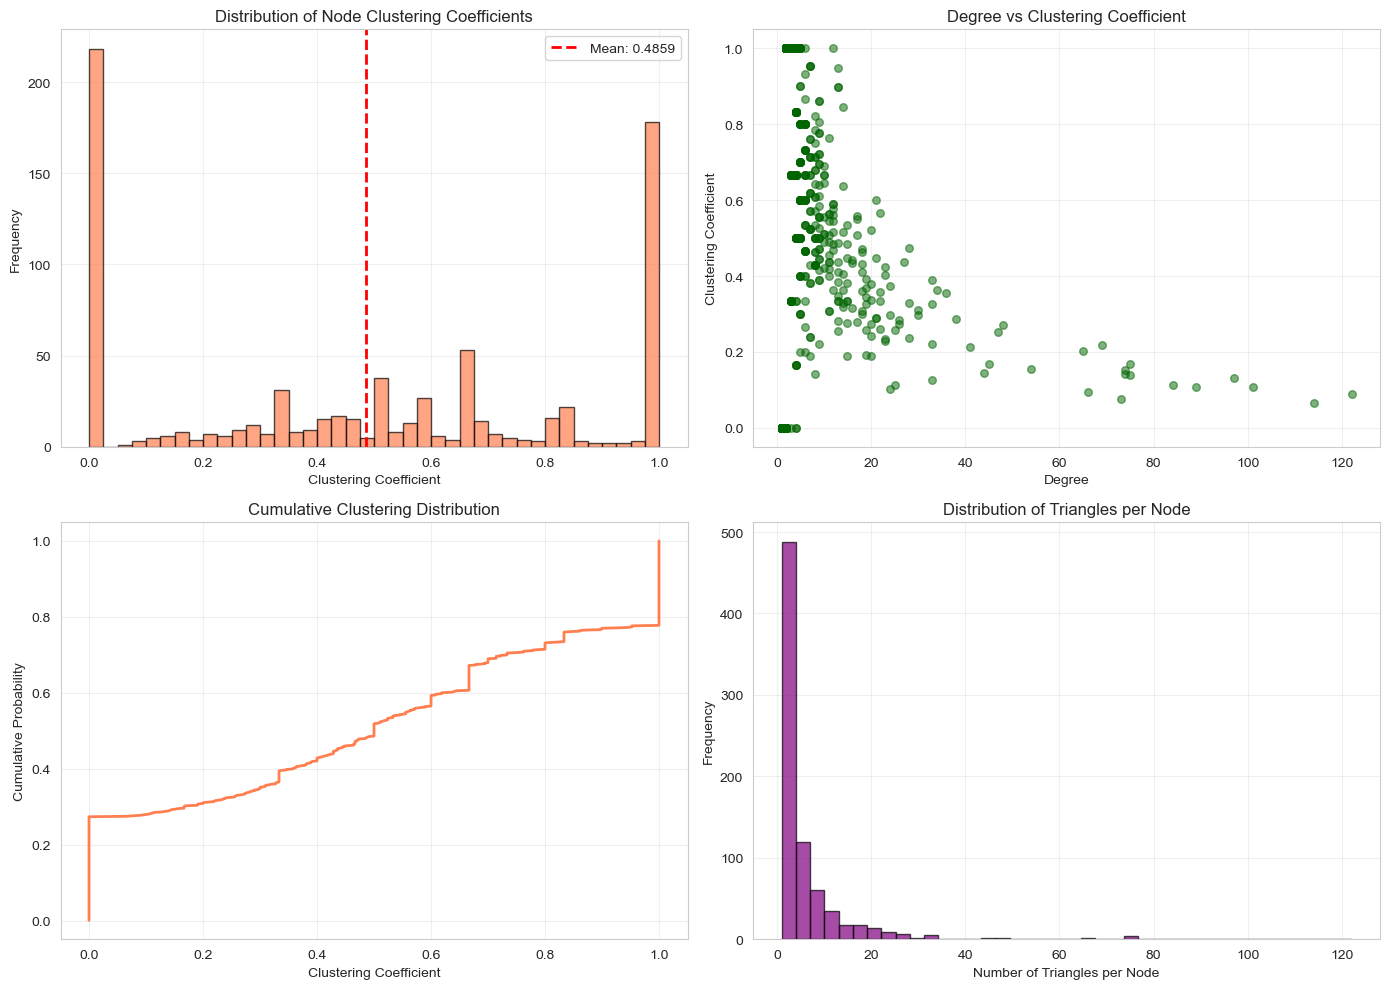

In [12]:
# 4. NETWORK-LEVEL CLUSTERING & COMMUNITY STRUCTURE

print("=" * 80)
print("NETWORK-LEVEL CLUSTERING & TRIADIC CLOSURE")
print("=" * 80)
print()

# Compute clustering metrics for main component
clustering_coeffs_main = nx.clustering(G_main)
transitivity_main = nx.transitivity(G_main)
avg_clustering_main = nx.average_clustering(G_main)

print("CLUSTERING STATISTICS:")
print(f"  Average clustering coefficient: {avg_clustering_main:.4f}")
print(f"  Network transitivity (global clustering): {transitivity_main:.4f}")
print()

# Compare with random network (Erdos-Renyi)
avg_degree = 2 * G_main.number_of_edges() / G_main.number_of_nodes()
prob_random = avg_degree / (G_main.number_of_nodes() - 1)
expected_clustering_random = prob_random

print("COMPARISON WITH RANDOM NETWORKS:")
print(f"  Random network clustering (Erdos-Renyi): {expected_clustering_random:.4f}")
print(f"  Actual clustering: {avg_clustering_main:.4f}")
print(f"  Clustering enhancement factor: {avg_clustering_main / expected_clustering_random:.2f}x")
print()

# Count triangles
triangles_count = {}
for node in G_main.nodes():
    triangles_count[node] = len(list(nx.common_neighbors(G_main, node, node)))

total_triangles = sum(triangles_count.values()) // 6  # Each triangle counted 6 times

print(f"TRIANGLE ANALYSIS:")
print(f"  Total triangles: {total_triangles}")
print(f"  Nodes in triangles: {sum(1 for t in triangles_count.values() if t > 0)}")
print(f"  Average triangles per node: {np.mean(list(triangles_count.values())):.2f}")
print(f"  Maximum triangles (any single node): {max(triangles_count.values())}")
print()

# Transitivity interpretation
print("INTERPRETATION OF NETWORK CLUSTERING:")
if transitivity_main > 0.3:
    print(f"  High clustering ({transitivity_main:.4f}): Network has strong local group structure")
elif transitivity_main > 0.1:
    print(f"  Moderate clustering ({transitivity_main:.4f}): Network has some local group structure")
else:
    print(f"  Low clustering ({transitivity_main:.4f}): Network is relatively tree-like")

print()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Clustering distribution
clustering_values_main = list(clustering_coeffs_main.values())
axes[0, 0].hist(clustering_values_main, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(avg_clustering_main, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_clustering_main:.4f}')
axes[0, 0].set_xlabel('Clustering Coefficient')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Node Clustering Coefficients')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Degree vs Clustering scatter
degree_clustering_pairs = [(degree_dict_main[n], clustering_coeffs_main[n]) for n in G_main.nodes()]
deg_vals, clust_vals = zip(*degree_clustering_pairs)

axes[0, 1].scatter(deg_vals, clust_vals, alpha=0.5, s=30, color='darkgreen')
axes[0, 1].set_xlabel('Degree')
axes[0, 1].set_ylabel('Clustering Coefficient')
axes[0, 1].set_title('Degree vs Clustering Coefficient')
axes[0, 1].grid(True, alpha=0.3)

# Cumulative clustering
sorted_clustering = sorted(clustering_values_main)
cumulative_clustering = np.arange(1, len(sorted_clustering) + 1) / len(sorted_clustering)
axes[1, 0].plot(sorted_clustering, cumulative_clustering, linewidth=2, color='coral')
axes[1, 0].set_xlabel('Clustering Coefficient')
axes[1, 0].set_ylabel('Cumulative Probability')
axes[1, 0].set_title('Cumulative Clustering Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Triangle count distribution (log scale for visibility)
triangle_values = list(triangles_count.values())
axes[1, 1].hist(triangle_values, bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Triangles per Node')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Triangles per Node')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

## 5. Comprehensive Macroscale Summary

In [13]:
# 5. COMPREHENSIVE MACROSCALE SUMMARY

print("=" * 100)
print("MACROSCALE ANALYSIS COMPREHENSIVE SUMMARY")
print("=" * 100)
print()

# Create summary table
summary_data_macro = []

# 1. Connectivity
summary_data_macro.append({
    'Category': 'Connectivity',
    'Measure': 'Connected Components',
    'Value': f'{num_components}',
    'Main Component': f'{component_sizes[0]}/{G.number_of_nodes()} nodes'
})

# 2. Distance metrics
if nx.is_connected(G_main):
    summary_data_macro.append({
        'Category': 'Distance',
        'Measure': 'Diameter',
        'Value': f'{diameter}',
        'Main Component': 'Longest shortest path'
    })
    summary_data_macro.append({
        'Category': 'Distance',
        'Measure': 'Avg Shortest Path',
        'Value': f'{avg_shortest_path:.4f}',
        'Main Component': 'Average distance'
    })

# 3. Degree distribution
summary_data_macro.append({
    'Category': 'Degree',
    'Measure': 'Mean Degree',
    'Value': f'{np.mean(degrees_main):.2f}',
    'Main Component': f'Total: {2*G_main.number_of_edges()/G_main.number_of_nodes():.2f}'
})
summary_data_macro.append({
    'Category': 'Degree',
    'Measure': 'Degree Range',
    'Value': f'{min(degrees_main)} - {max(degrees_main)}',
    'Main Component': f'Std dev: {np.std(degrees_main):.2f}'
})

if len(nonzero_centers) > 2:
    summary_data_macro.append({
        'Category': 'Degree',
        'Measure': 'Power-Law Exponent (γ)',
        'Value': f'{alpha:.4f}',
        'Main Component': 'Scale-free' if 2 < alpha < 3 else 'Non-scale-free'
    })

# 4. Clustering
summary_data_macro.append({
    'Category': 'Clustering',
    'Measure': 'Average Clustering',
    'Value': f'{avg_clustering_main:.4f}',
    'Main Component': f'{avg_clustering_main/expected_clustering_random:.2f}x random'
})
summary_data_macro.append({
    'Category': 'Clustering',
    'Measure': 'Network Transitivity',
    'Value': f'{transitivity_main:.4f}',
    'Main Component': 'Global clustering'
})

# 5. Assortativity
summary_data_macro.append({
    'Category': 'Correlations',
    'Measure': 'Degree Assortativity',
    'Value': f'{assortativity:.4f}',
    'Main Component': 'Assortative' if assortativity > 0 else 'Disassortative'
})

# Print as formatted table
df_summary_macro = pd.DataFrame(summary_data_macro)
print(df_summary_macro.to_string(index=False))
print()

# Key findings
print("=" * 100)
print("KEY MACROSCALE FINDINGS")
print("=" * 100)
print()

print("1. NETWORK CONNECTIVITY:")
print(f"   - The network has {num_components} component(s)")
if num_components == 1:
    print(f"   - Network is fully connected")
else:
    print(f"   - Largest component contains {100*component_sizes[0]/G.number_of_nodes():.1f}% of nodes")
print()

print("2. GLOBAL DISTANCES:")
if nx.is_connected(G_main):
    print(f"   - Network diameter: {diameter} (max distance between any two nodes)")
    print(f"   - Average shortest path: {avg_shortest_path:.4f} (typical distance between nodes)")
    
    # Small-world check
    expected_diameter_log = np.log(G_main.number_of_nodes())/np.log(2*G_main.number_of_edges()/G_main.number_of_nodes())
    if diameter <= 1.5 * expected_diameter_log:
        print(f"   - SMALL-WORLD PROPERTY: YES (diameter matches log(N) scaling)")
    else:
        print(f"   - SMALL-WORLD PROPERTY: NO (diameter > expected log(N))")
print()

print("3. DEGREE DISTRIBUTION:")
print(f"   - Mean degree: {np.mean(degrees_main):.2f} (typical connections per node)")
print(f"   - Degree range: {min(degrees_main)}-{max(degrees_main)} (heterogeneity indicator)")

if len(nonzero_centers) > 2:
    if 2 < alpha < 3:
        print(f"   - Power-law exponent γ = {alpha:.4f}: SCALE-FREE NETWORK")
        print(f"     → Network has hubs and is robust to random failures but vulnerable to targeted attacks")
    else:
        print(f"   - Power-law exponent γ = {alpha:.4f}: NON-SCALE-FREE NETWORK")
print()

print("4. CLUSTERING & TRIADIC CLOSURE:")
print(f"   - Network transitivity: {transitivity_main:.4f}")
print(f"   - Clustering level: {avg_clustering_main/expected_clustering_random:.2f}x higher than random network")
print(f"   - Total triangles: {total_triangles}")
print(f"   - Interpretation: Network exhibits {'strong' if transitivity_main > 0.3 else 'moderate' if transitivity_main > 0.1 else 'weak'} local clustering")
print()

print("5. DEGREE CORRELATIONS (ASSORTATIVITY):")
print(f"   - Assortativity coefficient: {assortativity:.4f}")
if assortativity > 0.1:
    print(f"   - ASSORTATIVE: High-degree nodes connect to other high-degree nodes")
    print(f"     → Network has hierarchical 'hubs-and-spokes' structure")
elif assortativity < -0.1:
    print(f"   - DISASSORTATIVE: High-degree nodes connect to low-degree nodes")
    print(f"     → Network is heterogeneous with central hubs")
else:
    print(f"   - NEUTRAL: No strong degree correlation")
print()

print("=" * 100)
print("NETWORK CLASSIFICATION")
print("=" * 100)
print()

# Classify network type based on properties
network_type = []

# Check for scale-free
if len(nonzero_centers) > 2 and 2 < alpha < 3:
    network_type.append("Scale-Free")

# Check for small-world
if nx.is_connected(G_main) and avg_clustering_main > 0.1 and avg_shortest_path < np.log(G_main.number_of_nodes()):
    network_type.append("Small-World")

# Check for assortative
if assortativity > 0.1:
    network_type.append("Assortative (Social-like)")
elif assortativity < -0.1:
    network_type.append("Disassortative (Hub-dominated)")

print("Characteristics observed in this network:")
if network_type:
    for i, typ in enumerate(network_type, 1):
        print(f"  {i}. {typ}")
else:
    print("  - Mixed or intermediate network type")

print()
print("Comparison with reference networks:")
print(f"  - Random Erdos-Renyi: Clustering ≈ {expected_clustering_random:.4f}, Diameter ≈ ln(N)")
print(f"  - Lattice/Regular: Clustering ≈ 0.5, High diameter")
print(f"  - Scale-Free: γ ∈ (2,3), High clustering, Low diameter")
print()


MACROSCALE ANALYSIS COMPREHENSIVE SUMMARY

    Category                Measure   Value        Main Component
Connectivity   Connected Components       1         796/796 nodes
    Distance               Diameter       9 Longest shortest path
    Distance      Avg Shortest Path  3.4162      Average distance
      Degree            Mean Degree    7.09           Total: 7.09
      Degree           Degree Range 1 - 122        Std dev: 12.68
      Degree Power-Law Exponent (γ)  1.9477        Non-scale-free
  Clustering     Average Clustering  0.4859         54.46x random
  Clustering   Network Transitivity  0.2090     Global clustering
Correlations   Degree Assortativity -0.1154        Disassortative

KEY MACROSCALE FINDINGS

1. NETWORK CONNECTIVITY:
   - The network has 1 component(s)
   - Network is fully connected

2. GLOBAL DISTANCES:
   - Network diameter: 9 (max distance between any two nodes)
   - Average shortest path: 3.4162 (typical distance between nodes)
   - SMALL-WORLD PROPERTY:

## 6. Comparative Network Metrics Visualization

MACROSCALE METRICS COMPARISON



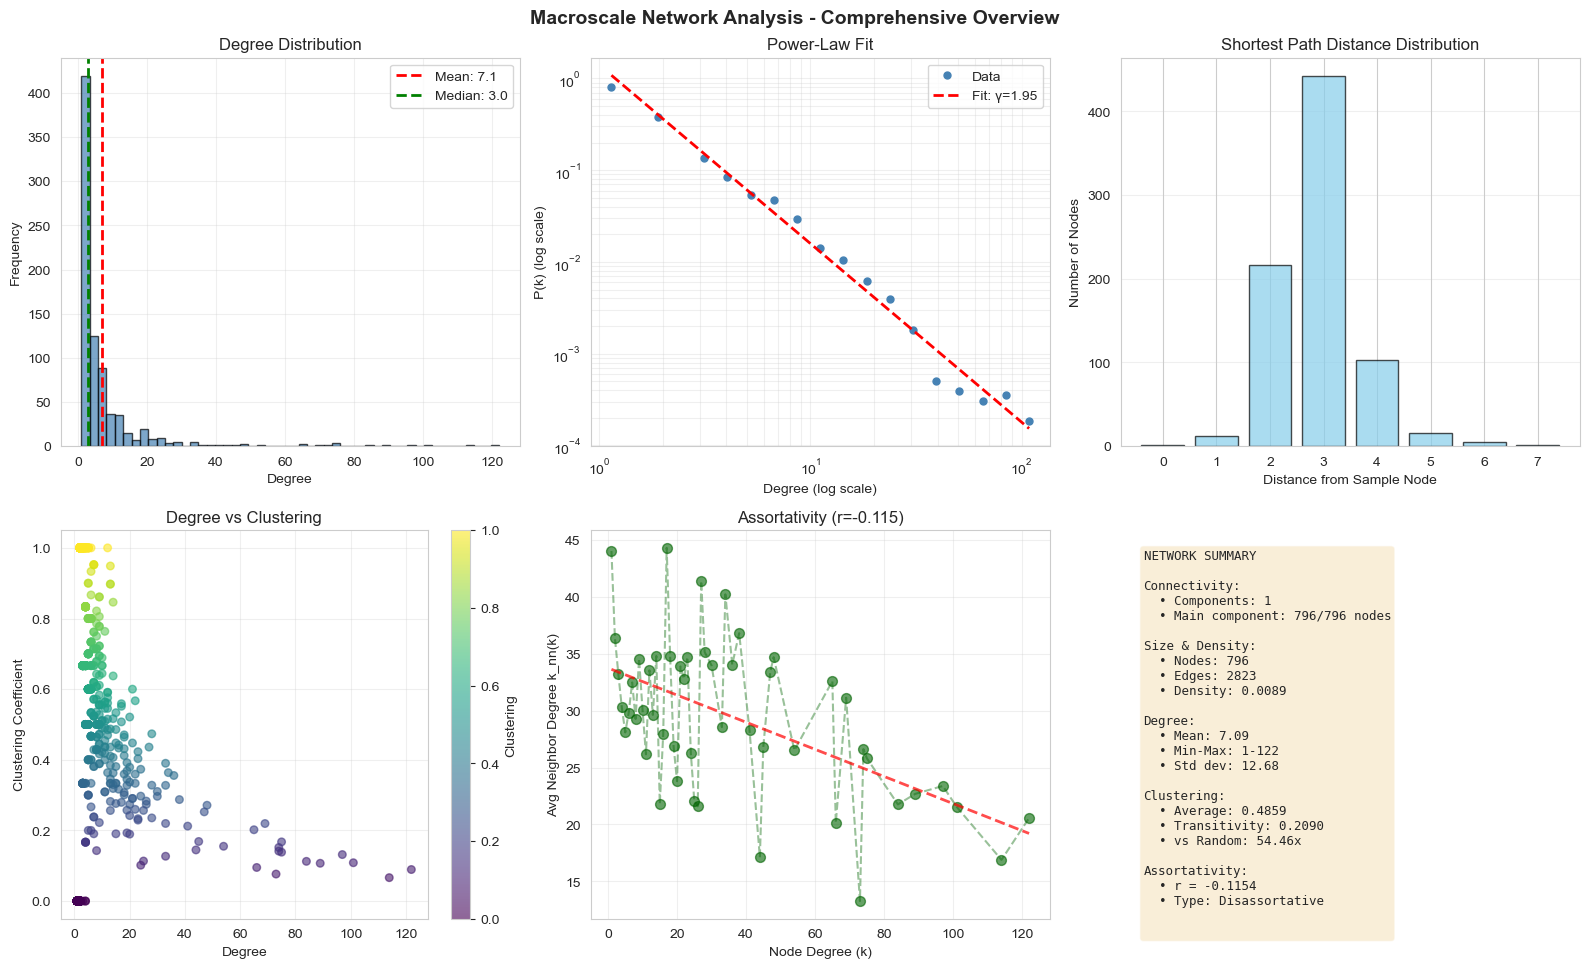

Visualization complete.



In [16]:
# 6. COMPARATIVE NETWORK METRICS VISUALIZATION

print("=" * 80)
print("MACROSCALE METRICS COMPARISON")
print("=" * 80)
print()

# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Macroscale Network Analysis - Comprehensive Overview', fontsize=14, fontweight='bold')

# 1. Degree distribution with key metrics
ax = axes[0, 0]
ax.hist(degrees_main, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(degrees_main), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(degrees_main):.1f}')
ax.axvline(np.median(degrees_main), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(degrees_main):.1f}')
ax.set_xlabel('Degree')
ax.set_ylabel('Frequency')
ax.set_title('Degree Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Degree distribution (log-log)
ax = axes[0, 1]
if len(nonzero_centers) > 2:
    ax.loglog(nonzero_centers, nonzero_prob, 'o', color='steelblue', markersize=5, label='Data')
    fit_line = np.exp(np.polyval(coeffs, np.log(nonzero_centers)))
    ax.loglog(nonzero_centers, fit_line, 'r--', linewidth=2, label=f'Fit: γ={alpha:.2f}')
    ax.legend()
ax.set_xlabel('Degree (log scale)')
ax.set_ylabel('P(k) (log scale)')
ax.set_title('Power-Law Fit')
ax.grid(True, alpha=0.3, which='both')

# 3. Distance histogram
ax = axes[0, 2]
if nx.is_connected(G_main):
    sample_node = list(G_main.nodes())[0]
    path_lengths = nx.single_source_shortest_path_length(G_main, sample_node)
    dist_counts = {}
    for dist in path_lengths.values():
        dist_counts[dist] = dist_counts.get(dist, 0) + 1
    
    ax.bar(dist_counts.keys(), dist_counts.values(), color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Distance from Sample Node')
    ax.set_ylabel('Number of Nodes')
    ax.set_title('Shortest Path Distance Distribution')
    ax.grid(True, alpha=0.3, axis='y')

# 4. Clustering vs Degree
ax = axes[1, 0]
degree_list = [degree_dict_main[n] for n in G_main.nodes()]
clustering_list = [clustering_coeffs_main[n] for n in G_main.nodes()]
scatter = ax.scatter(degree_list, clustering_list, c=clustering_list, cmap='viridis', alpha=0.6, s=30)
ax.set_xlabel('Degree')
ax.set_ylabel('Clustering Coefficient')
ax.set_title('Degree vs Clustering')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Clustering')

# 5. k_nn(k) - Assortativity plot
ax = axes[1, 1]
k_vals = sorted(knn_by_degree.keys())
knn_vals = [knn_by_degree[k] for k in k_vals]
ax.scatter(k_vals, knn_vals, alpha=0.6, s=50, color='darkgreen')
if len(k_vals) > 1:
    ax.plot(k_vals, knn_vals, '--', alpha=0.4, color='darkgreen')
    
    # Add trend line
    if len(k_vals) > 2:
        z = np.polyfit(k_vals, knn_vals, 1)
        p = np.poly1d(z)
        ax.plot(k_vals, p(k_vals), 'r--', alpha=0.7, linewidth=2)

ax.set_xlabel('Node Degree (k)')
ax.set_ylabel('Avg Neighbor Degree k_nn(k)')
ax.set_title(f'Assortativity (r={assortativity:.3f})')
ax.grid(True, alpha=0.3)

# 6. Network statistics summary (text box)
ax = axes[1, 2]
ax.axis('off')

summary_text = f"""NETWORK SUMMARY

Connectivity:
  • Components: {num_components}
  • Main component: {component_sizes[0]}/{G.number_of_nodes()} nodes

Size & Density:
  • Nodes: {G_main.number_of_nodes()}
  • Edges: {G_main.number_of_edges()}
  • Density: {nx.density(G_main):.4f}

Degree:
  • Mean: {np.mean(degrees_main):.2f}
  • Min-Max: {min(degrees_main)}-{max(degrees_main)}
  • Std dev: {np.std(degrees_main):.2f}

Clustering:
  • Average: {avg_clustering_main:.4f}
  • Transitivity: {transitivity_main:.4f}
  • vs Random: {avg_clustering_main/expected_clustering_random:.2f}x

Assortativity:
  • r = {assortativity:.4f}
  • Type: {'Assortative' if assortativity > 0 else 'Disassortative'}

"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Visualization complete.")
print()